# CHronoZ Benchmark Modelling
## Non-Standard Delta Model Audit

**Discrete, Robust, Regime-Conditioned, and Structural-Epoch Benchmark Experiments**

Many CHronoZ series may support transformed Delta Distributions. These six have zero changes, discrete steps, crisis tails, or possible policy/structural shifts. This notebook tests alternatives; it does not force them into Gaussian normalization or select a production architecture.

References: [main delta study](analysis.ipynb), [PPIACO audit](audit-PPIACO.ipynb), and [PCEC96 audit](audit-PCEC96.ipynb). Only local cleaned data are used. No historical observations are deleted or winsorized.

**Timing:** each latest observation is held out from reference fitting. Earlier scores, thresholds, groups and historical diagnostics are retrospective, not real-time backtests. Weekly regime labels use the preceding 13 weeks, excluding the scored week, but their percentile thresholds are fitted on the pre-latest sample. Source vintages may contain revisions. Full-history statistics describe all available changes; calibration uses pre-latest values. The printed cutoffs identify the snapshot reference.

## Configuration and data validation

Thresholds are editable development choices, not economic truths. Native frequency is retained. Monthly gaps invalidate a change and any rolling window spanning the missing value; weekly steps require exactly seven days. All invalid-pair counts are reported. Undefined zero-scale scores remain missing, with the fallback documented below.

In [1]:
from pathlib import Path
from decimal import Decimal
import hashlib,platform,itertools
import numpy as np
import pandas as pd
import scipy,matplotlib
from scipy.stats import skew,kurtosis
import matplotlib.pyplot as plt
from IPython.display import display,Markdown,HTML
CONFIG={ # DEVELOPMENT / AUDIT THRESHOLDS ONLY
 'zero_share_threshold':.20,'modified_z_threshold':3.5,
 'rolling_window_monthly':60,'rolling_window_weekly':13,
 'tail_ratio_threshold':1.5,'regime_upper_percentile':.80,'regime_lower_percentile':.20,
 'rolling_std_ratio_threshold':3.,'rolling_mean_span_threshold':2.,
 'epoch_scale_ratio_threshold':3.,'epoch_center_shift_threshold':1.,
 'min_group_observations':30,'score_change_threshold':1.,'material_score_change_share':.05,
 'rarity_common_probability':.10,'rarity_less_common_probability':.03,'rarity_rare_probability':.01,
 'strong_direction_quantile':.90,'strong_excess_kurtosis':10.,
 'epochs_two':['2008-01-01'],'epochs_three':['2008-01-01','2020-01-01']}
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/cleaned/series_metadata.csv').is_file()),None)
if ROOT is None:raise FileNotFoundError('Run inside the repository.')
IDS=['AWHAETP','ICSA','UNRATE','WALCL','WRESBAL','TOTRESNS']
NAMES={'AWHAETP':'Average Weekly Hours: Total Private','ICSA':'Initial Claims','UNRATE':'Unemployment Rate',
 'WALCL':'Federal Reserve Total Assets','WRESBAL':'Reserve Balances with Federal Reserve Banks','TOTRESNS':'Total Reserves of Depository Institutions'}
MODELS=dict(zip(IDS,['DISCRETE_DELTA','ROBUST_DELTA','DISCRETE_PLUS_SHOCK','REGIME_DELTA','REGIME_ROBUST_DELTA','STRUCTURAL_EPOCH_DELTA']))
METHODS={s:'arithmetic' if s in ['AWHAETP','UNRATE'] else 'log' for s in IDS}
UNITS={'AWHAETP':'Hours change','UNRATE':'Percentage-point change'}
def units(s):return UNITS.get(s,'100 x native-step log ratio')
def digest(p):return hashlib.sha256(p.read_bytes()).hexdigest()
protected=list((ROOT/'data/cleaned').glob('*.csv'))+list((ROOT/'notebook/deltaAnalysis').glob('*.ipynb'))
protected=[p for p in protected if p.name!='audit-nonstandard-delta-models.ipynb']
hashes={str(p.relative_to(ROOT)):digest(p) for p in protected}
def table(frame):display(HTML(frame.to_html(index=False,float_format=lambda x:f'{x:,.5g}',escape=True)))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'figure.facecolor':'white','axes.spines.top':False,'axes.spines.right':False})
meta=pd.read_csv(ROOT/'data/cleaned/series_metadata.csv').set_index('series_id')
DATA={};inventory=[];precision={}
for sid in IDS:
 path=ROOT/'data/cleaned'/f'{sid}.csv';d=pd.read_csv(path);assert list(d)==['date','value']
 d=d.rename(columns={'value':'level'});d['date']=pd.to_datetime(d.date);d['level']=pd.to_numeric(d.level)
 assert d.date.notna().all() and d.date.is_unique and d.date.is_monotonic_increasing and np.isfinite(d.level).all()
 assert len(d)==meta.loc[sid,'valid_observations']
 DATA[sid]=d
 strings=pd.read_csv(path,dtype=str)['value']
 precision[sid]=max(max(0,-Decimal(v).as_tuple().exponent) for v in strings)
 inventory.append({'series':sid,'name':NAMES[sid],'start':d.date.min(),'end':d.date.max(),'observations':len(d),
 'frequency':meta.loc[sid,'expected_frequency'],'missing_values':d.isna().sum().sum(),'minimum':d.level.min(),'maximum':d.level.max(),
 'reference_cutoff':d.date.iloc[-2]})
table(pd.DataFrame(inventory))


series,name,start,end,observations,frequency,missing_values,minimum,maximum,reference_cutoff
AWHAETP,Average Weekly Hours: Total Private,2006-03-01,2026-08-01,246,monthly,0,33.7,35,2026-07-01
ICSA,Initial Claims,1967-01-07,2026-09-12,3115,weekly,0,1.62e+05,6.137e+06,2026-09-05
UNRATE,Unemployment Rate,1948-01-01,2026-08-01,943,monthly,0,2.5,14.8,2026-07-01
WALCL,Federal Reserve Total Assets,2002-12-18,2026-09-09,1239,weekly,0,7.1281e+05,8.9655e+06,2026-09-02
WRESBAL,Reserve Balances with Federal Reserve Banks,2002-12-18,2026-09-09,1239,weekly,0,"2,795",4.2758e+06,2026-09-02
TOTRESNS,Total Reserves of Depository Institutions,1959-01-01,2026-07-01,811,monthly,0,18,"4,193.2",2026-06-01


## Shared calculations and candidate mapping

Arithmetic change = X(t)-X(t-1); log change = 100 ln(X(t)/X(t-1)); percent change = 100(X(t)/X(t-1)-1). Log/percent candidates require positive endpoints here. Sample std uses ddof=1. MAD is unscaled median absolute deviation. Robust z = (x-median)/(1.4826 MAD). Modified z = 0.6745(x-median)/MAD. Empirical percentile = 100 times the reference proportion less than or equal to the observation (ties share the upper rank).

For an unusable MAD, robust scoring falls back to IQR/1.349 only if positive; if both are zero the score is undefined and no tail flag is assigned. The UNRATE modified-z detector uses equivalent 0.6745 scaling with MAD, or the IQR fallback without claiming it is the same detector. Reference counts and scale methods are visible.

All mappings below are hypotheses to test, not decisions.

In [2]:
def consecutive(dates,freq):
 return dates.diff().eq(pd.Timedelta(days=7)) if freq=='weekly' else dates.dt.to_period('M').astype('int64').diff().eq(1)
def change(d,freq,method):
 prev=d.level.shift();step=consecutive(d.date,freq);paired=prev.notna();positive=(d.level>0)&(prev>0)
 eligible=step&paired
 bad_positive=eligible&~positive if method in ['log','percent'] else pd.Series(False,index=d.index)
 if method in ['log','percent']:eligible=eligible&positive
 a,b=d.level.where(eligible),prev.where(eligible)
 result=a-b if method=='arithmetic' else 100*np.log(a/b) if method=='log' else 100*(a/b-1)
 bad_finite=eligible&~np.isfinite(result);result=result.where(~bad_finite)
 return result,{'gap_pairs':int((paired&~step).sum()),'nonpositive_pairs':int(bad_positive.sum()),'nonfinite_pairs':int(bad_finite.sum()),'valid_deltas':int(result.notna().sum())}
def stats(v):
 s=pd.Series(v).dropna();m=s.median()
 return {'count':len(s),'mean':s.mean(),'std':s.std(ddof=1),'median':m,'MAD':(s-m).abs().median(),
 'skewness':s.skew(),'kurtosis':s.kurt(),'zero_share':s.eq(0).mean(),'minimum':s.min(),'maximum':s.max(),
 **{f'P{q}':s.quantile(q/100) for q in [1,5,25,50,75,95,99]}}
def robust_scale(v):
 s=pd.Series(v).dropna();mad=(s-s.median()).abs().median()
 if mad>np.finfo(float).eps:return 1.4826*mad,'MAD'
 iqr=s.quantile(.75)-s.quantile(.25)
 return (iqr/1.349,'IQR fallback') if iqr>np.finfo(float).eps else (np.nan,'undefined: zero MAD and IQR')
def score(values,reference):
 r=pd.Series(reference).dropna();scale,method=robust_scale(r);sd=r.std(ddof=1)
 return pd.DataFrame({'global_z':(values-r.mean())/sd if sd>0 else np.nan,
 'global_robust_z':(values-r.median())/scale,
 'percentile':np.where(pd.Series(values).notna(),100*np.searchsorted(np.sort(r),values,side='right')/len(r),np.nan)},index=values.index),method
def caption(s,d,description):
 return f'{s}: {NAMES[s]}\n{description} | {d.date.min():%Y-%m-%d} to {d.date.max():%Y-%m-%d} | n={d.delta.notna().sum()}'
def hist(s,d,description):
 v=d.delta.dropna();edges=np.histogram_bin_edges(v,bins='auto')
 if len(edges)-1>80:edges=np.linspace(v.min(),v.max(),81)
 fig,(a,b)=plt.subplots(2,1,figsize=(11,6),sharex=True,gridspec_kw={'height_ratios':[4,1]},layout='constrained')
 a.hist(v,bins=edges,color='#3576A8',edgecolor='white');a.set_ylabel('Observation count')
 b.boxplot(v,orientation='horizontal',flierprops={'markersize':3});b.set_yticks([]);b.set_xlabel(units(s))
 for ax in (a,b):ax.axvline(v.mean(),color='#AB6400',ls='--',label='Mean');ax.axvline(v.median(),color='#222222',ls=':',label='Median')
 a.legend(frameon=False);fig.suptitle(caption(s,d,description),fontsize=11);plt.show();plt.close(fig)
def timeline(s,d,description):
 fig,ax=plt.subplots(figsize=(11,4),layout='constrained');ax.plot(d.date,d.delta,color='#3576A8',lw=1)
 ax.set(title=caption(s,d,description),xlabel='Observation date',ylabel=units(s));plt.show();plt.close(fig)
D={};REF={};AUDIT=[];S={};DIAG={};RESULTS={}
for sid in IDS:
 d=DATA[sid].copy();freq=meta.loc[sid,'expected_frequency'];d['previous_level']=d.level.shift()
 d['delta'],audit=change(d,freq,METHODS[sid])
 if sid in ['AWHAETP','UNRATE']:d['delta']=d.delta.round(precision[sid])
 d['eligible']=d.date.lt(d.date.max());ref=d.loc[d.eligible,'delta'].dropna()
 scores,scale_method=score(d.delta,ref);d=pd.concat([d,scores],axis=1)
 D[sid]=d;REF[sid]=ref;S[sid]=stats(d.delta);AUDIT.append({'series':sid,**audit,'scale_method':scale_method,'measurement_decimals':precision[sid]})
 # Reindex to native calendar before rolling: no compression across missing periods.
 grid=pd.date_range(d.date.min(),d.date.iloc[-2],freq='7D' if freq=='weekly' else 'MS')
 x=d.set_index('date').delta.reindex(grid);w=CONFIG['rolling_window_weekly'] if freq=='weekly' else CONFIG['rolling_window_monthly']
 rm=x.rolling(w,min_periods=w).mean();rs=x.rolling(w,min_periods=w).std()
 scale,_=robust_scale(ref);std_ratio=rs.quantile(.9)/rs.quantile(.1)
 mean_span=(rm.quantile(.9)-rm.quantile(.1))/scale
 DIAG[sid]={'tail_ratio':ref.std(ddof=1)/scale,'rolling_mean_instability':mean_span,
 'rolling_std_instability':std_ratio,'lag1_autocorrelation':d.loc[d.eligible,'delta'].autocorr(),
 'structural_instability_high':bool(std_ratio>CONFIG['rolling_std_ratio_threshold'] or mean_span>CONFIG['rolling_mean_span_threshold'])}
table(pd.DataFrame(AUDIT));table(pd.DataFrame([{'series':s,'candidate_model':MODELS[s],'primary_transform':METHODS[s]} for s in IDS]))
# Gap boundary check: September-to-November cannot become a one-month delta.
probe=pd.DataFrame({'date':pd.to_datetime(['2025-09-01','2025-11-01','2025-12-01']),'level':[100.,110.,121.]})
assert change(probe,'monthly','log')[0].iloc[:2].isna().all()


series,gap_pairs,nonpositive_pairs,nonfinite_pairs,valid_deltas,scale_method,measurement_decimals
AWHAETP,0,0,0,245,MAD,1
ICSA,0,0,0,3114,MAD,0
UNRATE,1,0,0,941,MAD,1
WALCL,0,0,0,1238,MAD,0
WRESBAL,0,0,0,1238,MAD,0
TOTRESNS,0,0,0,810,MAD,1


series,candidate_model,primary_transform
AWHAETP,DISCRETE_DELTA,arithmetic
ICSA,ROBUST_DELTA,log
UNRATE,DISCRETE_PLUS_SHOCK,arithmetic
WALCL,REGIME_DELTA,log
WRESBAL,REGIME_ROBUST_DELTA,log
TOTRESNS,STRUCTURAL_EPOCH_DELTA,log


## 1. AWHAETP: discrete empirical delta

Arithmetic hours changes are rounded only to the maximum recorded decimal precision in the source CSV, verified below. This removes floating-point subtraction artifacts, not economic variation. PMF and cumulative probability use pre-latest changes. Rarity = 1 - PMF probability: it measures rarity of an exact outcome, not directional tail probability. COMMON requires probability >= 0.10, LESS COMMON >= 0.03, RARE >= 0.01, otherwise VERY RARE (editable in CONFIG). An unseen latest outcome receives probability zero, not a claim of impossibility.

series,zero_share,unique_deltas,minimum,maximum,source_decimal_precision,direction_negative,direction_flat,direction_positive
AWHAETP,0.47951,8,-0.4,0.5,1,0.25,0.47951,0.27049


delta,count,probability,cumulative_probability
-0.4,2,0.0081967,0.0081967
-0.2,11,0.045082,0.053279
-0.1,48,0.19672,0.25
0,117,0.47951,0.72951
0.1,57,0.23361,0.96311
0.2,7,0.028689,0.9918
0.3,1,0.0040984,0.9959
0.5,1,0.0040984,1


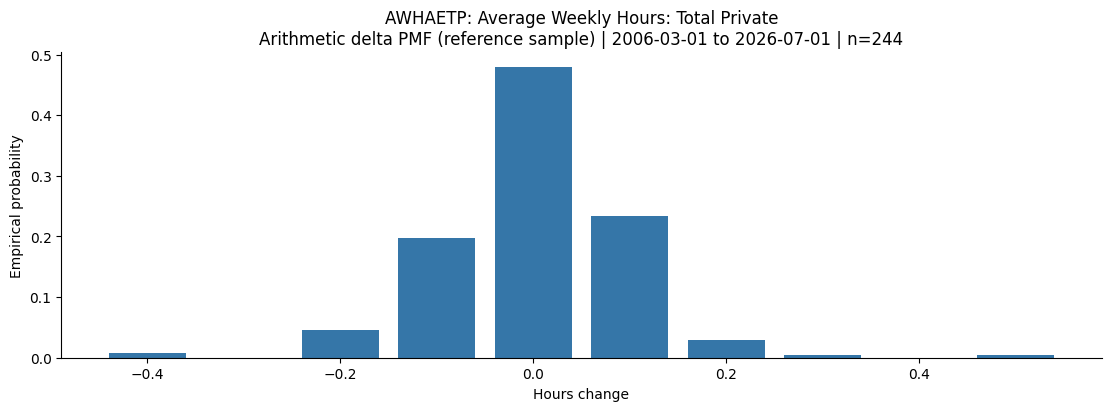

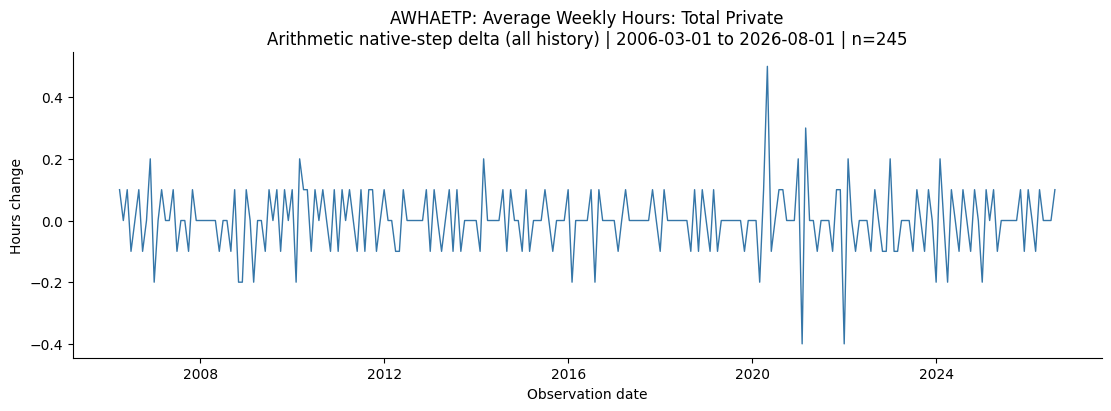

date,level,previous_level,delta,historical_probability,percentile,rarity,rarity_state
2026-08-01,34.4,34.3,0.1,0.23361,96.311,0.76639,COMMON


**Transition matrix: rows = previous delta; columns = current delta. Sparse rows are uncertain.**

delta,previous_delta,-0.4,-0.2,-0.1,0.0,0.1,0.2,0.3,0.5
,-0.4,0,0,0,0,0,0.5,0.5,0
,-0.2,0,0.090909,0,0.27273,0.45455,0.18182,0,0
,-0.1,0,0,0.0625,0.35417,0.54167,0.041667,0,0
,0,0,0.043103,0.22414,0.5431,0.17241,0.017241,0,0
,0.1,0.017544,0.070175,0.29825,0.52632,0.070175,0,0,0.017544
,0.2,0.14286,0.14286,0.14286,0.42857,0.14286,0,0,0
,0.3,0,0,0,1,0,0,0,0
,0.5,0,0,1,0,0,0,0,0


previous_delta,current_delta,count
0,0,63
0.1,0,30
0,-0.1,26
-0.1,0.1,26
0,0.1,20
-0.1,0,17
0.1,-0.1,17
-0.2,0.1,5
0,-0.2,5
0.1,-0.2,4


Zero share 48.0%; 8 distinct recorded steps support a discrete representation. A discrete empirical model represents flat months explicitly; continuous normalization would obscure that point mass. Next audit transition support and stability by period.

In [3]:
def discrete_audit(s):
 d=D[s].copy();ref=REF[s]
 pmf=ref.value_counts().sort_index().rename_axis('delta').reset_index(name='count')
 pmf['probability']=pmf['count']/pmf['count'].sum();pmf['cumulative_probability']=pmf.probability.cumsum()
 probability=pmf.set_index('delta').probability
 d['historical_probability']=d.delta.map(probability).fillna(0).where(d.delta.notna())
 d['rarity']=1-d.historical_probability
 d['rarity_state']=d.historical_probability.map(lambda p:'COMMON' if p>=CONFIG['rarity_common_probability'] else 'LESS COMMON' if p>=CONFIG['rarity_less_common_probability'] else 'RARE' if p>=CONFIG['rarity_rare_probability'] else 'VERY RARE')
 table(pd.DataFrame([{'series':s,'zero_share':ref.eq(0).mean(),'unique_deltas':ref.nunique(),'minimum':ref.min(),'maximum':ref.max(),'source_decimal_precision':precision[s],**{'direction_'+k:v for k,v in {'negative':ref.lt(0).mean(),'flat':ref.eq(0).mean(),'positive':ref.gt(0).mean()}.items()}}]))
 table(pmf)
 fig,ax=plt.subplots(figsize=(11,4),layout='constrained');ax.bar(pmf.delta,pmf.probability,width=.8*10**(-precision[s]),color='#3576A8')
 ax.set(title=caption(s,d.loc[d.eligible],'Arithmetic delta PMF (reference sample)'),xlabel=units(s),ylabel='Empirical probability');plt.show();plt.close(fig)
 timeline(s,d,'Arithmetic native-step delta (all history)')
 d.loc[d.delta.isna(),'rarity_state']='UNDEFINED'
 return d,pmf
aw,aw_pmf=discrete_audit('AWHAETP')
table(aw.tail(1)[['date','level','previous_level','delta','historical_probability','percentile','rarity','rarity_state']])
# Transitions require two valid consecutive deltas, never bridging a missing month.
mask=aw.eligible & aw.delta.notna() & aw.delta.shift().notna() & consecutive(aw.date,'monthly')
transition_counts=pd.crosstab(aw.delta.shift().loc[mask],aw.delta.loc[mask])
transition=transition_counts.div(transition_counts.sum(axis=1),axis=0)
display(Markdown('**Transition matrix: rows = previous delta; columns = current delta. Sparse rows are uncertain.**'))
table(transition.rename_axis('previous_delta').reset_index())
table(transition_counts.rename_axis(index='previous_delta',columns='current_delta').stack().rename('count').reset_index().sort_values('count',ascending=False).head(10))
aw_fit='PROMISING' if REF['AWHAETP'].eq(0).mean()>CONFIG['zero_share_threshold'] else 'MIXED'
RESULTS['AWHAETP']={'preliminary_fit':aw_fit,'main_normalization':'PMF / ECDF / exact-value rarity','main_risk':'Sparse transitions and precision-dependent point probabilities',
 'reason':f"Zero share {REF['AWHAETP'].eq(0).mean():.1%}; {REF['AWHAETP'].nunique()} distinct recorded steps support a discrete representation."}
display(Markdown(RESULTS['AWHAETP']['reason']+' A discrete empirical model represents flat months explicitly; continuous normalization would obscure that point mass. Next audit transition support and stability by period.'))


## 2. ICSA: robust weekly log growth

Compare standard z with (growth - median)/(1.4826 MAD), retaining every tail. A score disagreement is highlighted when their absolute difference exceeds CONFIG's threshold. |robust z| > 3.5 flags TAIL_EVENT. A non-tail reference is a diagnostic comparison only: this notebook does not prescribe excluding claims crises from production calibration.

sample,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
Full history,3114,-0.0019083,6.726,-0.23613,2.5768,14.556,497.88,0.031471,-28.768,236.78,-14.031,-7.4872,-2.7054,-0.23613,2.4989,7.4758,14.842
Reference before holdout,3113,-0.00031037,6.7265,-0.23557,2.5749,14.557,497.88,0.031481,-28.768,236.78,-14.031,-7.4889,-2.7029,-0.23557,2.5036,7.4774,14.845
Non-tail reference experiment,3029,-0.18246,4.1384,-0.24661,2.4813,0.049579,0.4464,0.032354,-13.441,13.119,-10.527,-7.0867,-2.658,-0.24661,2.3325,6.7422,10.668


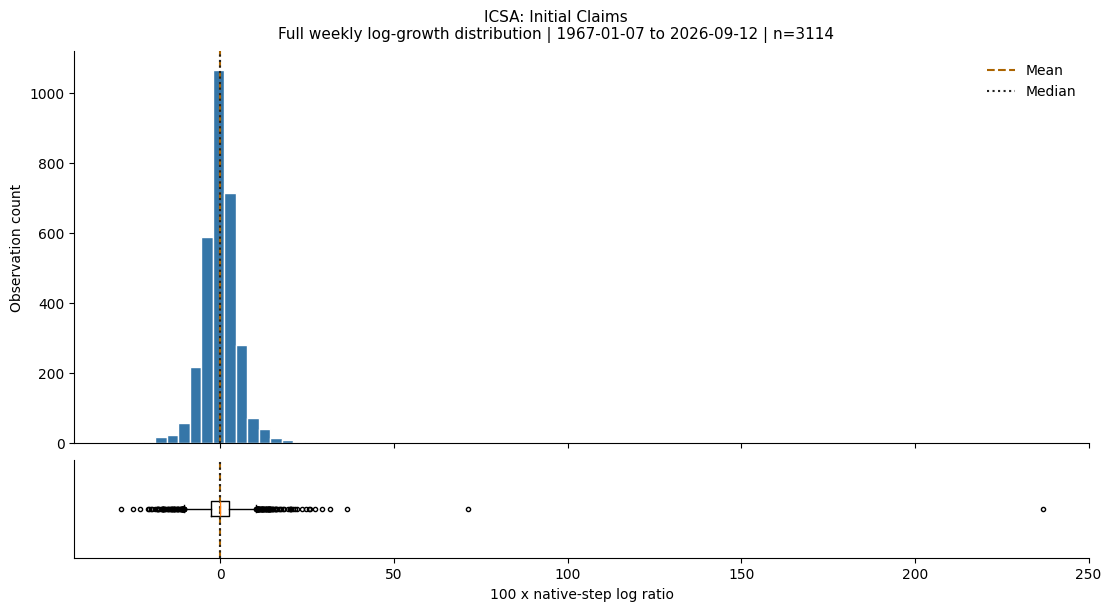

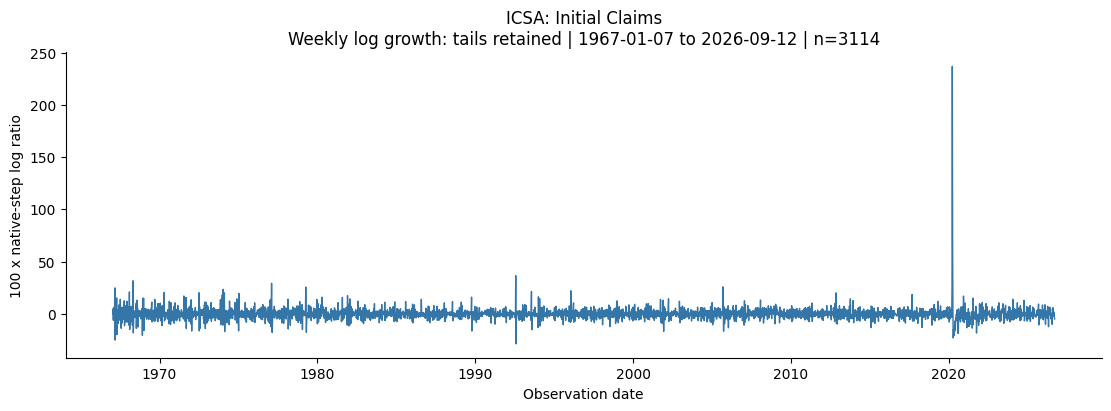

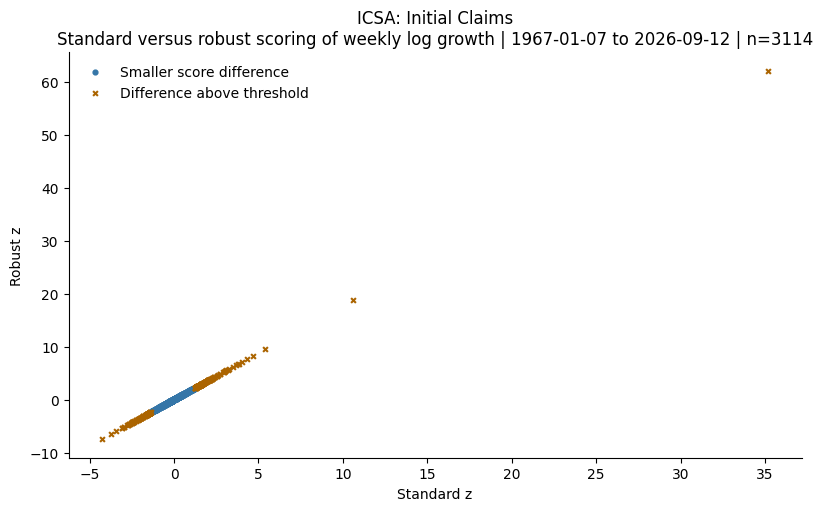

date,delta,global_z,global_robust_z,percentile,tail_flag,score_difference
2020-03-21,236.78,35.201,62.087,100,TAIL_EVENT,26.886
2020-03-28,71.319,10.603,18.744,99.968,TAIL_EVENT,8.1412
1992-07-25,36.379,5.4084,9.5913,99.936,TAIL_EVENT,4.183
1968-04-27,31.597,4.6974,8.3385,99.904,TAIL_EVENT,3.6412
1977-02-05,29.182,4.3384,7.706,99.872,TAIL_EVENT,3.3676
1992-08-01,-28.768,-4.2768,-7.4742,0.032123,TAIL_EVENT,3.1974
2020-03-14,27.193,4.0428,7.1851,99.839,TAIL_EVENT,3.1423
2005-09-10,25.811,3.8372,6.8229,99.807,TAIL_EVENT,2.9857
1979-04-07,25.593,3.8049,6.7659,99.775,TAIL_EVENT,2.9611
1967-03-04,24.763,3.6815,6.5486,99.743,TAIL_EVENT,2.867


date,delta,global_z,global_robust_z,percentile,tail_flag
2026-09-12,-4.9762,-0.73974,-1.2418,12.496,CENTRAL_REFERENCE


Standard/robust scale ratio 1.76; 84 observations flagged but retained. Robust normalization reduces the influence of tails on the scale estimate, which makes crisis scores larger, not smaller. A more stable scale is a hypothesis; evaluate expanding-window calibration and crisis subperiods next.

In [4]:
ic=D['ICSA'].copy();ic['tail_event']=ic.global_robust_z.abs().gt(CONFIG['modified_z_threshold'])
ic['tail_flag']=np.where(ic.tail_event,'TAIL_EVENT','CENTRAL_REFERENCE')
ic['score_difference']=(ic.global_z-ic.global_robust_z).abs()
table(pd.DataFrame([{'sample':'Full history',**stats(ic.delta)},
 {'sample':'Reference before holdout',**stats(REF['ICSA'])},
 {'sample':'Non-tail reference experiment',**stats(ic.loc[ic.eligible&~ic.tail_event,'delta'])}]))
hist('ICSA',ic,'Full weekly log-growth distribution');timeline('ICSA',ic,'Weekly log growth: tails retained')
fig,ax=plt.subplots(figsize=(8,5),layout='constrained')
for flag,color,label in [(False,'#3576A8','Smaller score difference'),(True,'#AB6400','Difference above threshold')]:
 part=ic.loc[ic.score_difference.gt(CONFIG['score_change_threshold']).eq(flag)]
 ax.scatter(part.global_z,part.global_robust_z,s=12,color=color,label=label,marker='x' if flag else 'o')
ax.set(title=caption('ICSA',ic,'Standard versus robust scoring of weekly log growth'),xlabel='Standard z',ylabel='Robust z');ax.legend(frameon=False);plt.show();plt.close(fig)
table(ic.nlargest(10,'score_difference')[['date','delta','global_z','global_robust_z','percentile','tail_flag','score_difference']])
table(ic.tail(1)[['date','delta','global_z','global_robust_z','percentile','tail_flag']])
ratio=DIAG['ICSA']['tail_ratio']
RESULTS['ICSA']={'preliminary_fit':'PROMISING' if ratio>CONFIG['tail_ratio_threshold'] else 'MIXED',
 'main_normalization':'Median/MAD robust z + ECDF','main_risk':'Crisis clustering; no proof of temporal stability',
 'reason':f'Standard/robust scale ratio {ratio:.2f}; {int(ic.tail_event.sum())} observations flagged but retained.'}
display(Markdown(RESULTS['ICSA']['reason']+' Robust normalization reduces the influence of tails on the scale estimate, which makes crisis scores larger, not smaller. A more stable scale is a hypothesis; evaluate expanding-window calibration and crisis subperiods next.'))


## 3. UNRATE: discrete changes plus shocks

Use arithmetic percentage-point changes, not percentage growth. Positive delta is deterioration in the unemployment rate; negative is improvement. |modified z| > 3.5 adds a shock label. If MAD is unusable, use the explicitly reported IQR fallback; if both scales are zero, mark the score/flag undefined rather than declaring no shocks.

Coarse STRONG direction bins use the pre-latest P90 of absolute nonzero changes; values strictly larger than that threshold are strong. These bins describe magnitude and direction, not economic causes.

series,zero_share,unique_deltas,minimum,maximum,source_decimal_precision,direction_negative,direction_flat,direction_positive
UNRATE,0.24468,26,-2.2,10.4,1,0.41064,0.24468,0.34468


delta,count,probability,cumulative_probability
-2.2,1,0.0010638,0.0010638
-1.8,1,0.0010638,0.0021277
-1.6,1,0.0010638,0.0031915
-1.5,1,0.0010638,0.0042553
-0.9,1,0.0010638,0.0053191
-0.8,1,0.0010638,0.006383
-0.7,1,0.0010638,0.0074468
-0.6,2,0.0021277,0.0095745
-0.5,7,0.0074468,0.017021
-0.4,19,0.020213,0.037234


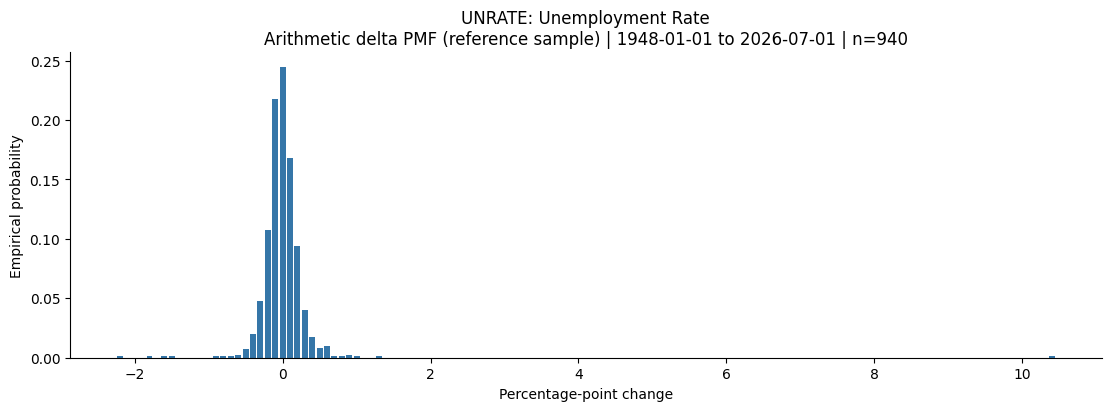

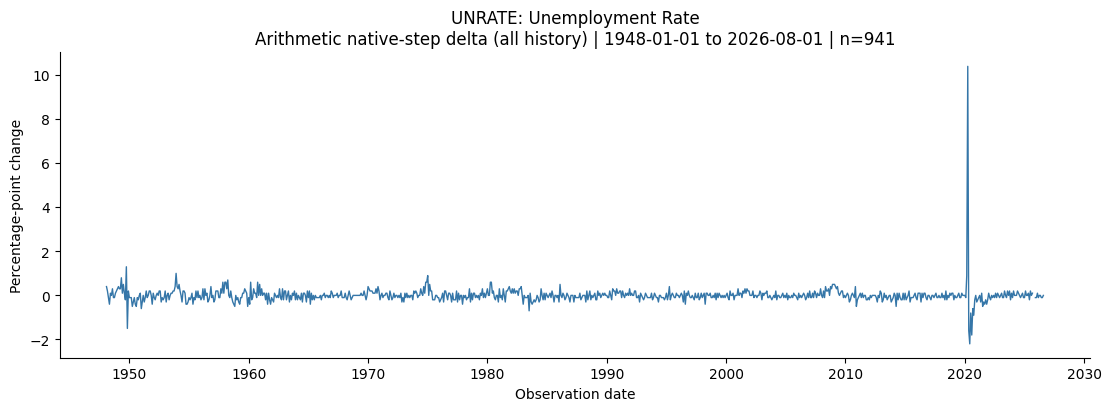

Scale method: MAD | strong-direction threshold (pp): 0.4


count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
941,0.00063762,0.41308,0,0.1,16.722,429.14,0.24548,-2.2,10.4,-0.5,-0.3,-0.1,0,0.1,0.3,0.6


state,coarse_state,count
DETERIORATION,DETERIORATION,300
DETERIORATION,STRONG_DETERIORATION,8
FLAT,FLAT,231
IMPROVEMENT,IMPROVEMENT,370
IMPROVEMENT,STRONG_IMPROVEMENT,7
SHOCK_DETERIORATION,STRONG_DETERIORATION,16
SHOCK_IMPROVEMENT,STRONG_IMPROVEMENT,9
UNDEFINED,UNDEFINED,2


date,delta,modified_z,state
2020-06-01,-2.2,-14.839,SHOCK_IMPROVEMENT
2020-08-01,-1.8,-12.141,SHOCK_IMPROVEMENT
2020-05-01,-1.6,-10.792,SHOCK_IMPROVEMENT
1949-11-01,-1.5,-10.117,SHOCK_IMPROVEMENT
2020-10-01,-0.9,-6.0705,SHOCK_IMPROVEMENT
2020-07-01,-0.8,-5.396,SHOCK_IMPROVEMENT
1983-07-01,-0.7,-4.7215,SHOCK_IMPROVEMENT
1951-01-01,-0.6,-4.047,SHOCK_IMPROVEMENT
2020-09-01,-0.6,-4.047,SHOCK_IMPROVEMENT
1980-05-01,0.6,4.047,SHOCK_DETERIORATION


date,level,delta,historical_probability,percentile,modified_z,shock_event,state
2026-08-01,4.1,0,0.24468,65.532,0,False,FLAT


Zero share 24.5%; 25 shocks; native precision 1 decimal place(s). The discrete representation separates ordinary steps from shocks without deleting either. Next review shock thresholds and rounded-value transitions across subperiods.

In [5]:
un,un_pmf=discrete_audit('UNRATE');ref=REF['UNRATE'];mad=(ref-ref.median()).abs().median()
scale,scale_method=robust_scale(ref)
un['modified_z']=.6745*(un.delta-ref.median())/mad if mad>np.finfo(float).eps else (un.delta-ref.median())/scale
un['shock_event']=un.modified_z.abs().gt(CONFIG['modified_z_threshold']).astype('boolean').mask(un.modified_z.isna())
strong_threshold=ref.loc[ref.ne(0)].abs().quantile(CONFIG['strong_direction_quantile'])
def shock_state(row):
 if pd.isna(row.delta) or pd.isna(row.shock_event):return 'UNDEFINED'
 direction='IMPROVEMENT' if row.delta<0 else 'DETERIORATION' if row.delta>0 else 'FLAT'
 return 'SHOCK_'+direction if row.shock_event and row.delta!=0 else direction
un['state']=un.apply(shock_state,axis=1)
un['coarse_state']=un.delta.map(lambda x:'UNDEFINED' if pd.isna(x) else 'FLAT' if x==0 else ('STRONG_' if abs(x)>strong_threshold else '')+('IMPROVEMENT' if x<0 else 'DETERIORATION'))
print('Scale method:',scale_method,'| strong-direction threshold (pp):',strong_threshold)
table(pd.DataFrame([stats(un.delta)]));table(un.groupby(['state','coarse_state']).size().reset_index(name='count'))
table(un.loc[un.shock_event.fillna(False),['date','delta','modified_z','state']].sort_values('modified_z'))
table(un.tail(1)[['date','level','delta','historical_probability','percentile','modified_z','shock_event','state']])
RESULTS['UNRATE']={'preliminary_fit':'PROMISING' if ref.eq(0).mean()>CONFIG['zero_share_threshold'] and un.shock_event.fillna(False).any() else 'MIXED',
 'main_normalization':'Discrete PMF + modified-z shock detector','main_risk':'Shock thresholds and zero-scale fallback need review',
 'reason':f'Zero share {ref.eq(0).mean():.1%}; {int(un.shock_event.fillna(False).sum())} shocks; native precision {precision["UNRATE"]} decimal place(s).'}
display(Markdown(RESULTS['UNRATE']['reason']+' The discrete representation separates ordinary steps from shocks without deleting either. Next review shock thresholds and rounded-value transitions across subperiods.'))


## 4. WALCL: experimental regime-conditioned delta

Use weekly log growth. Calculate trailing mean/std over the **preceding** 13 weeks (current delta excluded). Pre-latest P20/P80 of that rolling mean define CONTRACTION / NEUTRAL / EXPANSION speed buckets. A bucket name is relative to historical speed, not a claim about QE/QT or a guaranteed positive/negative change; actual threshold signs are shown. The first 14 rows lack sufficient prior deltas and stay UNCLASSIFIED, not discarded.

Conditioned mean/std, median/MAD and ECDF use only pre-latest observations in each bucket. Groups below the configured minimum count receive missing conditioned scores rather than unstable estimates. Global scores remain available. Changes in score interpretation do not prove a better predictive model; the fitted groups are evaluated in-sample retrospectively. Grouping is tested even if global instability is low, but that limits the conclusion.

series,rolling_mean_lower,rolling_mean_upper,unclassified_rows,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
WALCL,-0.1139,0.29521,14,1238,0.18072,1.4517,0.031023,0.30708,6.1421,74.949,0,-6.1048,21.599,-2.3415,-1.1548,-0.26857,0.031023,0.35486,1.7288,5.1846


regime,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99,robust_scale_method,score_available
CONTRACTION,245,-0.049357,0.92336,-0.13809,0.17963,4.4075,35.447,0,-4.0045,8.4472,-1.4277,-0.70376,-0.37631,-0.13809,0.028865,1.1848,3.886,MAD,True
EXPANSION,245,0.72321,2.7483,0.30928,0.4937,3.8812,24.43,0,-6.1048,21.599,-5.1284,-1.7562,-0.099429,0.30928,0.96913,5.0404,11.318,MAD,True
NEUTRAL,734,0.077864,0.7671,0.037512,0.29488,0.38674,2.5542,0,-3.3021,3.4783,-1.8996,-1.1009,-0.26202,0.037512,0.31368,1.5334,2.2837,MAD,True


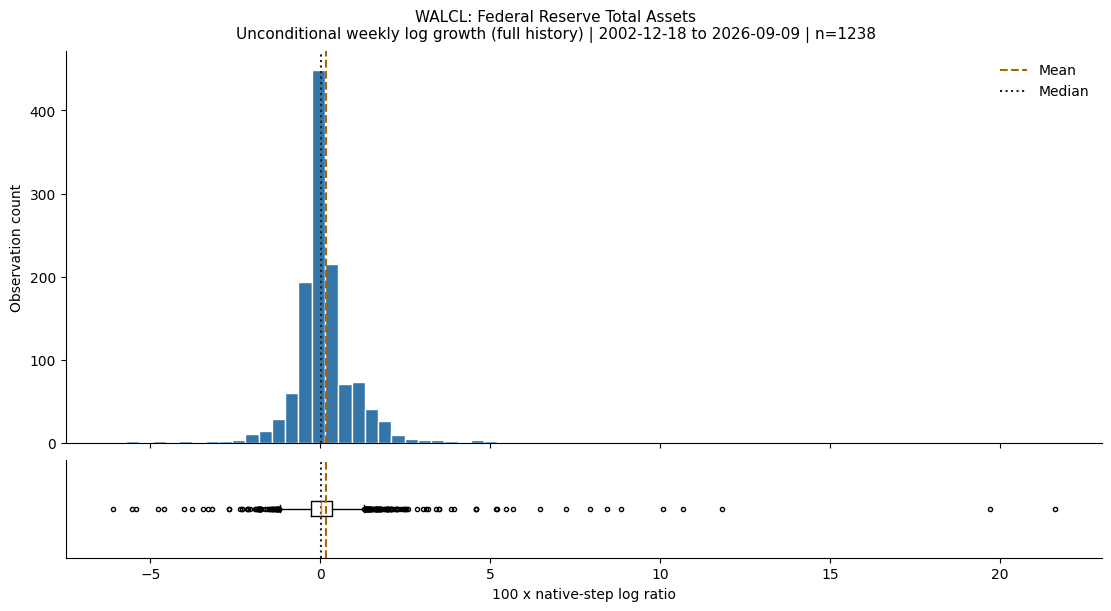

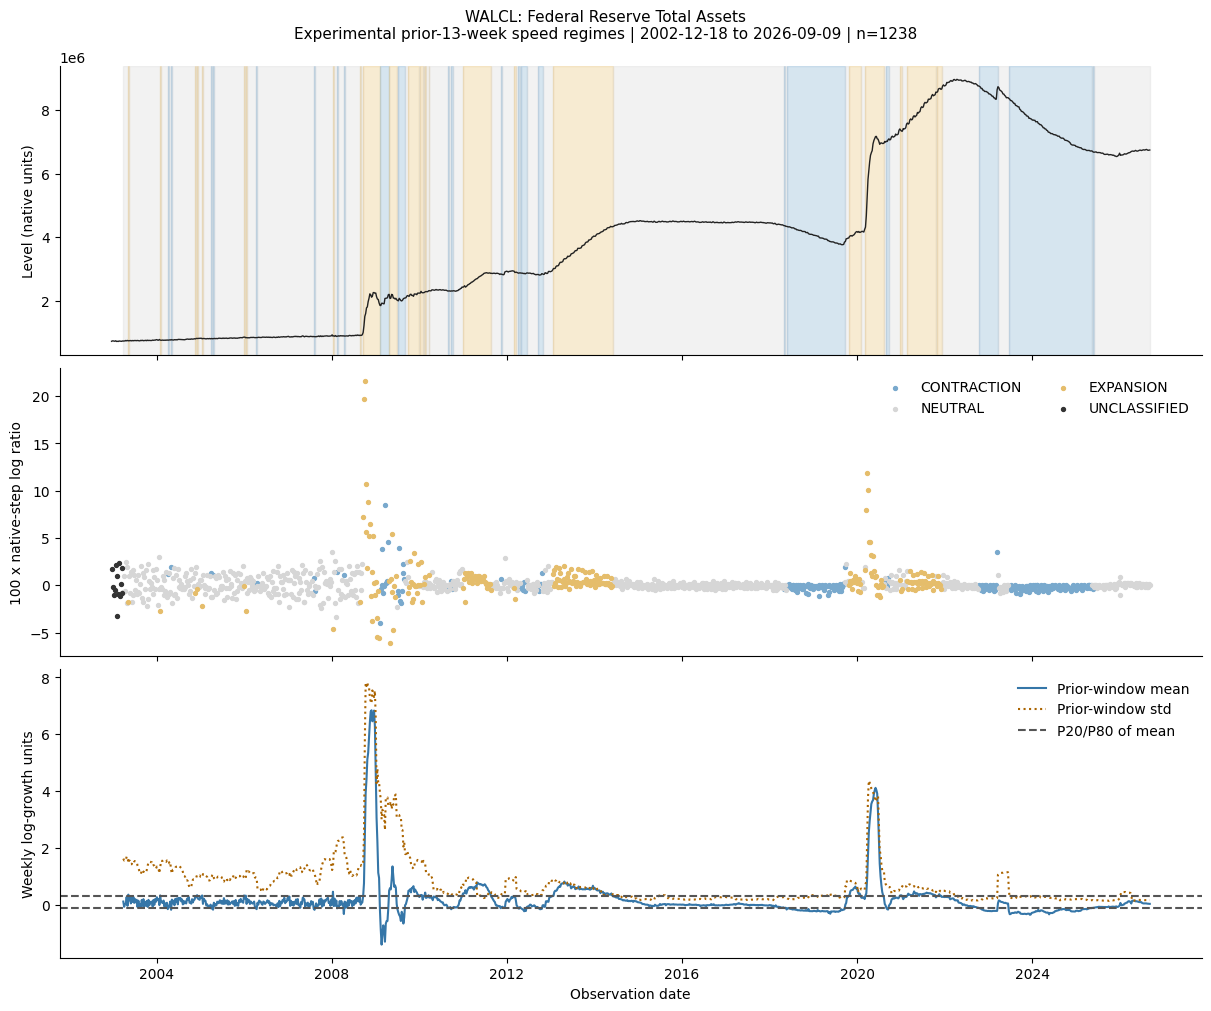

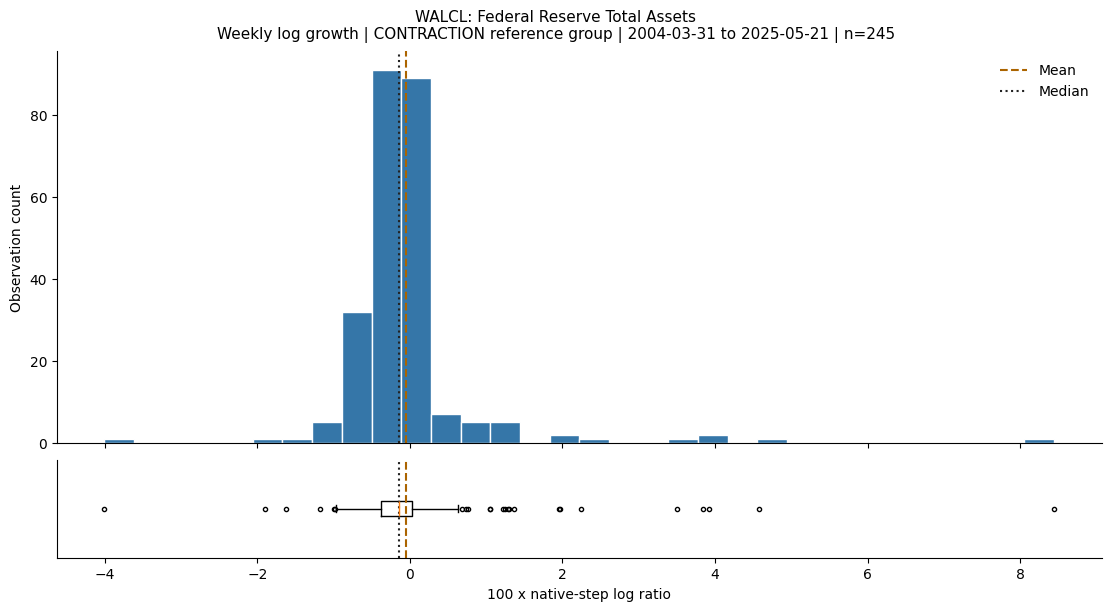

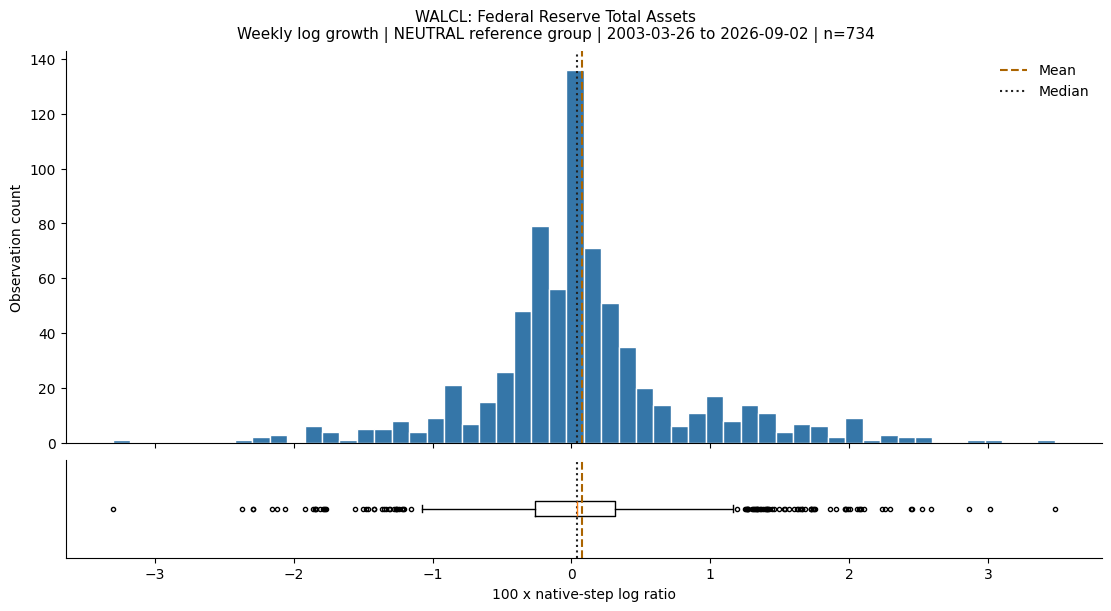

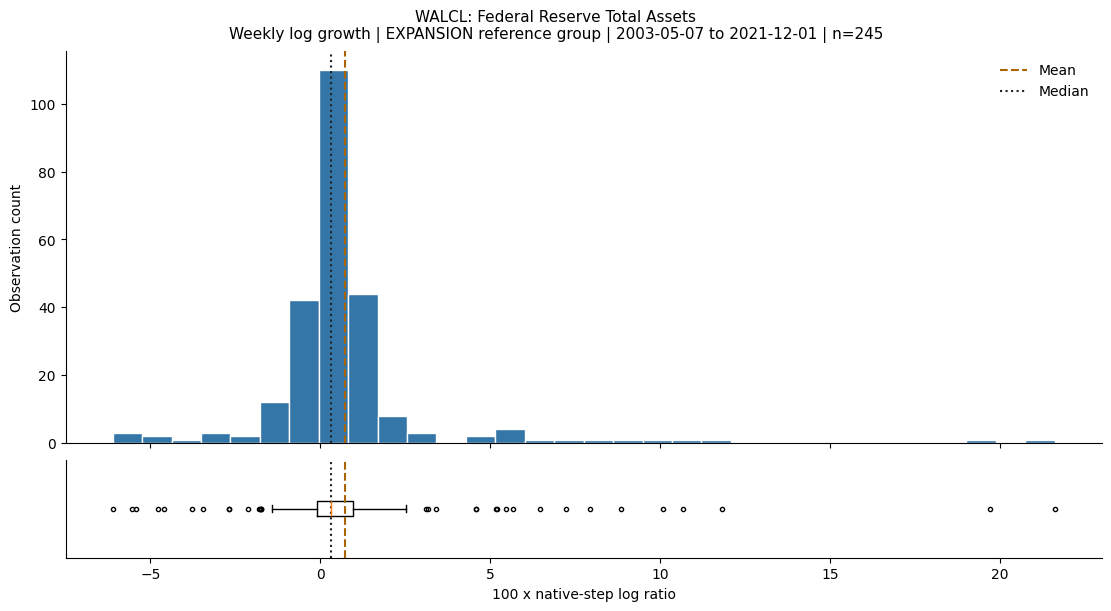

**Largest interpretation changes** (score differences, not evidence of better predictions):

date,delta,regime,global_z,global_robust_z,z_regime,robust_z_regime,standard_score_difference
2008-10-01,21.599,EXPANSION,14.748,47.348,7.5959,29.087,7.1525
2008-09-24,19.705,EXPANSION,13.444,43.189,6.9065,26.498,6.5372
2020-03-25,11.827,EXPANSION,8.0191,25.895,4.0401,15.735,3.979
2008-10-15,10.67,EXPANSION,7.223,23.357,3.6194,14.156,3.6036
2009-03-18,8.4472,CONTRACTION,5.6921,18.476,9.2018,32.237,3.5097
2020-04-01,10.081,EXPANSION,6.8174,22.063,3.4051,13.351,3.4123
2008-10-29,8.8338,EXPANSION,5.9583,19.325,2.9511,11.646,3.0072
2020-03-18,7.9395,EXPANSION,5.3425,17.361,2.6257,10.424,2.7168
2008-09-17,7.2259,EXPANSION,4.8511,15.795,2.366,9.4495,2.4851
2008-11-12,6.4704,EXPANSION,4.3309,14.136,2.0912,8.4174,2.2397


date,delta,regime,global_z,global_robust_z,z_regime,robust_z_regime,percentile_regime
2026-09-09,0.050676,NEUTRAL,-0.089617,0.043442,-0.035443,0.030111,53.951


6.8% of available scores change by more than 1.0 score unit(s); minimum group n=245; instability screen=True. Conditioning makes context explicit, but it also changes the reference by construction. Next test window/threshold sensitivity and held-out calibration before preferring it to a global reference.

In [6]:
REGIMES={};GROUP_TABLES={};REGIME_EFFECT={}
COLORS={'EXPANSION':'#E5BD6B','NEUTRAL':'#D6D6D6','CONTRACTION':'#79A9CD','UNCLASSIFIED':'#FFFFFF'}
def group_scores(d,column):
 out=d.copy();group_rows=[]
 for group,part in out.loc[out.eligible&out[column].ne('UNCLASSIFIED')].groupby(column):
  ref=part.delta.dropna();summary=stats(ref);scale,method=robust_scale(ref)
  group_rows.append({column:group,**summary,'robust_scale_method':method,'score_available':len(ref)>=CONFIG['min_group_observations']})
  mask=out[column].eq(group)&out.delta.notna()
  if len(ref)<CONFIG['min_group_observations']:continue
  out.loc[mask,'z_conditioned']=(out.loc[mask,'delta']-ref.mean())/ref.std(ddof=1) if ref.std(ddof=1)>0 else np.nan
  out.loc[mask,'robust_z_conditioned']=(out.loc[mask,'delta']-ref.median())/scale
  out.loc[mask,'percentile_conditioned']=100*np.searchsorted(np.sort(ref),out.loc[mask,'delta'],side='right')/len(ref)
 for col in ['z_conditioned','robust_z_conditioned','percentile_conditioned']:
  if col not in out:out[col]=np.nan
 return out,pd.DataFrame(group_rows)
def regime_experiment(s):
 d=D[s].copy();w=CONFIG['rolling_window_weekly']
 assert d.date.diff().iloc[1:].eq(pd.Timedelta(days=7)).all()
 d['rolling_mean_13w']=d.delta.shift(1).rolling(w,min_periods=w).mean()
 d['rolling_std_13w']=d.delta.shift(1).rolling(w,min_periods=w).std()
 fit=d.loc[d.eligible,'rolling_mean_13w'].dropna()
 lower=fit.quantile(CONFIG['regime_lower_percentile']);upper=fit.quantile(CONFIG['regime_upper_percentile'])
 d['regime']=np.select([d.rolling_mean_13w.isna(),d.rolling_mean_13w<lower,d.rolling_mean_13w>upper],['UNCLASSIFIED','CONTRACTION','EXPANSION'],default='NEUTRAL')
 d,groups=group_scores(d,'regime');d=d.rename(columns={'z_conditioned':'z_regime','robust_z_conditioned':'robust_z_regime','percentile_conditioned':'percentile_regime'})
 table(pd.DataFrame([{'series':s,'rolling_mean_lower':lower,'rolling_mean_upper':upper,'unclassified_rows':d.regime.eq('UNCLASSIFIED').sum(),**stats(d.delta)}]))
 table(groups)
 hist(s,d,'Unconditional weekly log growth (full history)')
 fig,(a,b,c)=plt.subplots(3,1,figsize=(12,10),sharex=True,layout='constrained')
 a.plot(d.date,d.level,color='#222222',lw=1)
 # Shade contiguous runs, with explicit legend on the delta scatter below.
 starts=np.flatnonzero(d.regime.ne(d.regime.shift()).to_numpy())
 for i,start in enumerate(starts):
  end=starts[i+1] if i+1<len(starts) else len(d)-1
  a.axvspan(d.date.iloc[start],d.date.iloc[end],color=COLORS[d.regime.iloc[start]],alpha=.3)
 for group in ['CONTRACTION','NEUTRAL','EXPANSION','UNCLASSIFIED']:
  part=d.loc[d.regime.eq(group)];b.scatter(part.date,part.delta,s=8,label=group,color=COLORS[group] if group!='UNCLASSIFIED' else '#333333')
 b.legend(frameon=False,ncol=2);a.set_ylabel('Level (native units)');b.set_ylabel(units(s))
 c.plot(d.date,d.rolling_mean_13w,color='#3576A8',label='Prior-window mean')
 c.plot(d.date,d.rolling_std_13w,color='#AB6400',ls=':',label='Prior-window std')
 c.axhline(lower,color='#555555',ls='--',label='P20/P80 of mean');c.axhline(upper,color='#555555',ls='--')
 c.set(ylabel='Weekly log-growth units',xlabel='Observation date');c.legend(frameon=False)
 fig.suptitle(caption(s,d,'Experimental prior-13-week speed regimes'),fontsize=11)
 plt.show();plt.close(fig)
 for group in ['CONTRACTION','NEUTRAL','EXPANSION']:
  hist(s,d.loc[d.regime.eq(group)&d.eligible],f'Weekly log growth | {group} reference group')
 d['standard_score_difference']=(d.global_z-d.z_regime).abs()
 d['robust_score_difference']=(d.global_robust_z-d.robust_z_regime).abs()
 effect_col='standard_score_difference' if s=='WALCL' else 'robust_score_difference'
 available=d.loc[d[effect_col].notna()]
 effect=available[effect_col].gt(CONFIG['score_change_threshold']).mean()
 display(Markdown('**Largest interpretation changes** (score differences, not evidence of better predictions):'))
 table(d.nlargest(10,effect_col)[['date','delta','regime','global_z','global_robust_z','z_regime','robust_z_regime',effect_col]])
 table(d.tail(1)[['date','delta','regime','global_z','global_robust_z','z_regime','robust_z_regime','percentile_regime']])
 REGIMES[s]=d;GROUP_TABLES[s]=groups;REGIME_EFFECT[s]=effect
 supported=groups.score_available.all() and groups['count'].min()>=CONFIG['min_group_observations']
 fit_label='MIXED' if not DIAG[s]['structural_instability_high'] or not supported else 'PROMISING' if effect>CONFIG['material_score_change_share'] else 'MIXED'
 RESULTS[s]={'preliminary_fit':fit_label,'main_normalization':'Within-regime median/MAD + ECDF' if s=='WRESBAL' else 'Within-regime standard and robust z + ECDF',
 'main_risk':'Retrospective thresholds; speed buckets are not identified policy regimes',
 'reason':f'{effect:.1%} of available scores change by more than {CONFIG["score_change_threshold"]} score unit(s); minimum group n={groups["count"].min()}; instability screen={DIAG[s]["structural_instability_high"]}.'}
 display(Markdown(RESULTS[s]['reason']+' Conditioning makes context explicit, but it also changes the reference by construction. Next test window/threshold sensitivity and held-out calibration before preferring it to a global reference.'))
regime_experiment('WALCL')


## 5. WRESBAL: regime-conditioned robust delta

Use weekly log growth only for positive consecutive endpoints; invalid-pair counts were shown in the global audit. This series is fully positive in the current snapshot. Apply the same prior-13-week speed buckets, emphasizing within-regime median/MAD and ECDF. Compare global standard z, global robust z, and regime robust z. This is a statistical liquidity-series experiment, not a causal model of liquidity operations.

series,rolling_mean_lower,rolling_mean_upper,unclassified_rows,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
WRESBAL,-0.57904,0.88534,14,1238,0.46875,23.5,0.17532,2.1636,0.45727,11.478,0,-152.09,169.13,-81.77,-34.416,-2.2107,0.17532,2.0756,43.027,78.384


regime,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99,robust_scale_method,score_available
CONTRACTION,245,14.369,30.555,1.599,5.6688,1.5556,3.8897,0,-44.957,169.13,-42.383,-21.724,-1.0832,1.599,27.964,67.708,102.08,MAD,True
EXPANSION,245,-9.5078,33.073,-0.64091,4.5134,-0.28727,5.1154,0,-152.09,165.07,-100.03,-76.782,-15.59,-0.64091,2.3389,25.432,77.709,MAD,True
NEUTRAL,734,-0.89098,10.305,0.045395,1.6,-3.2093,38.114,0,-114.43,74.27,-50.418,-6.7454,-1.7451,0.045395,1.487,5.2096,25.173,MAD,True


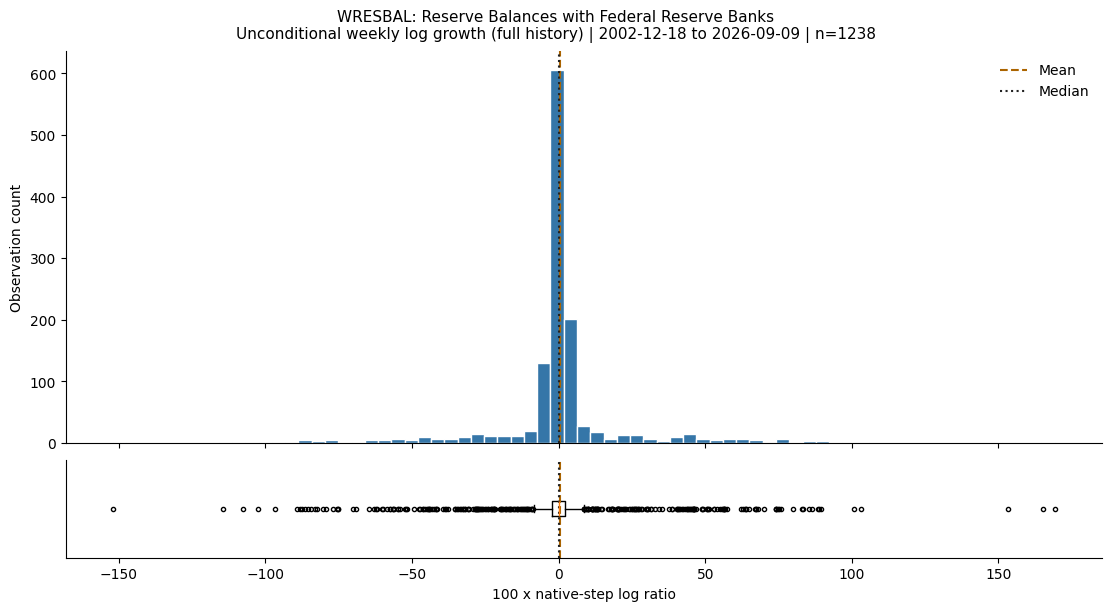

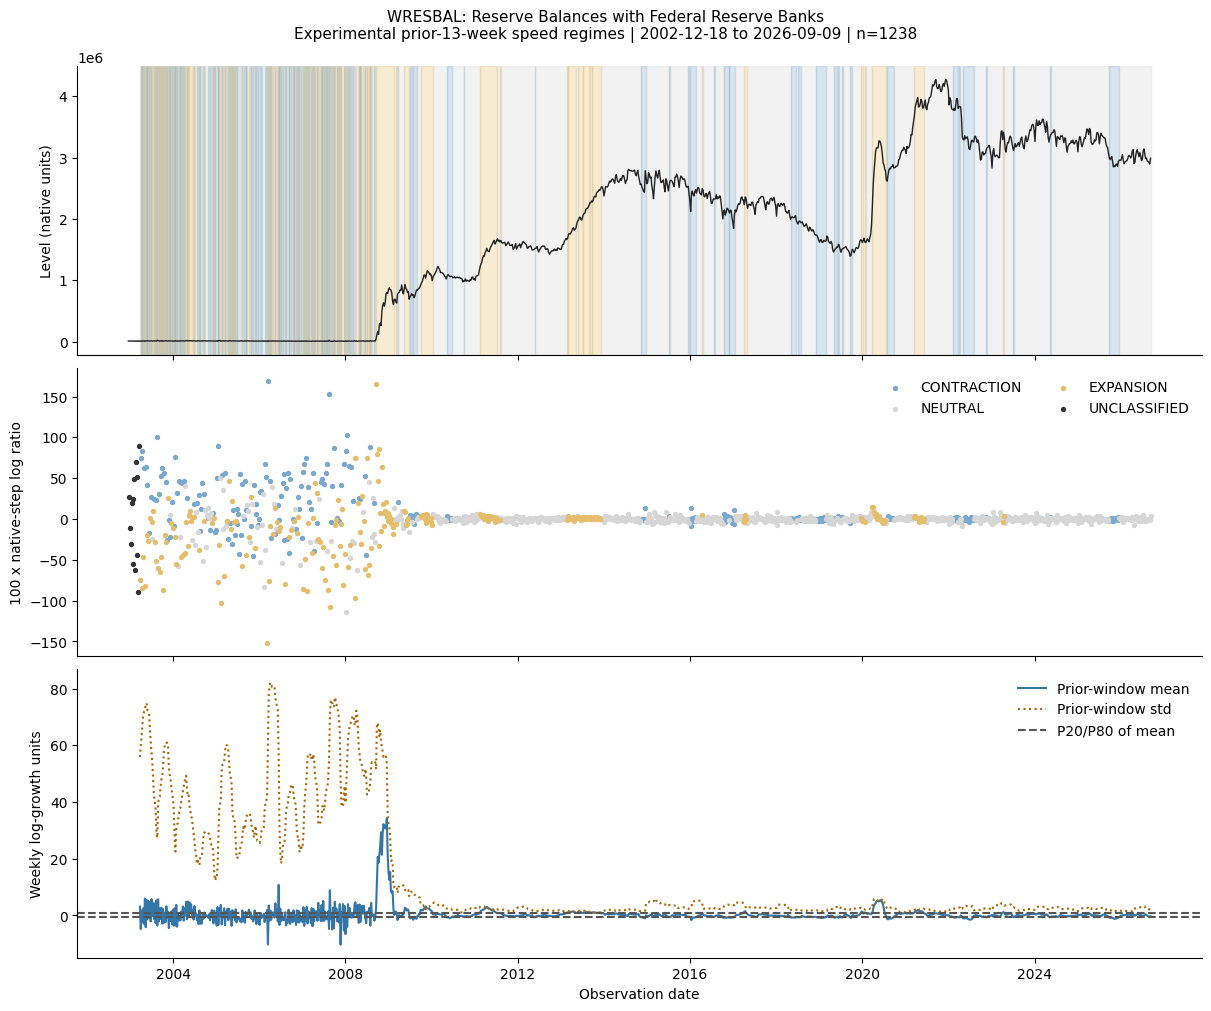

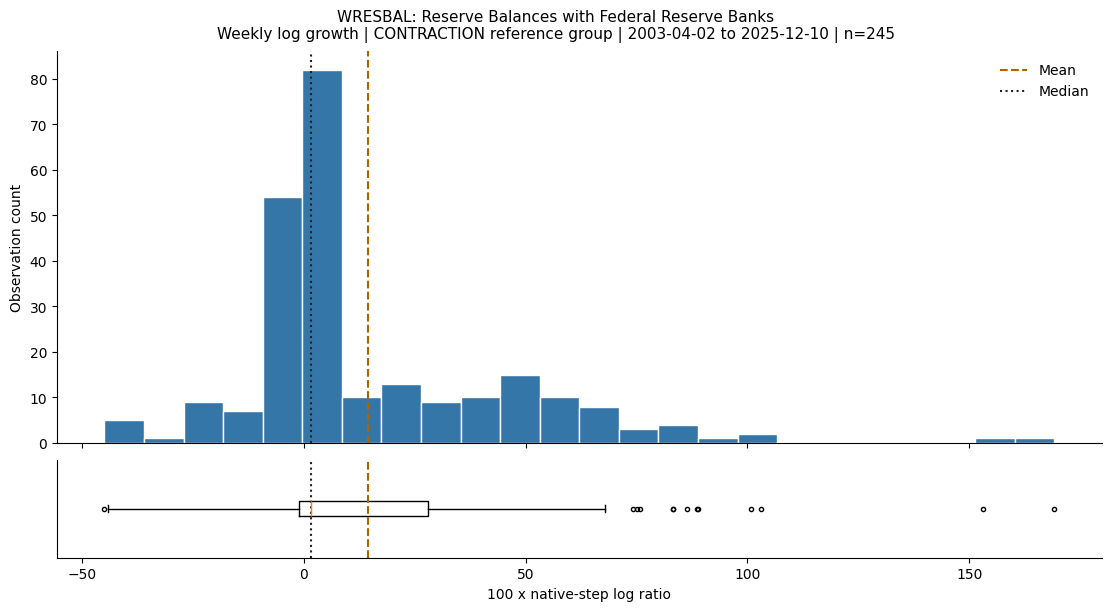

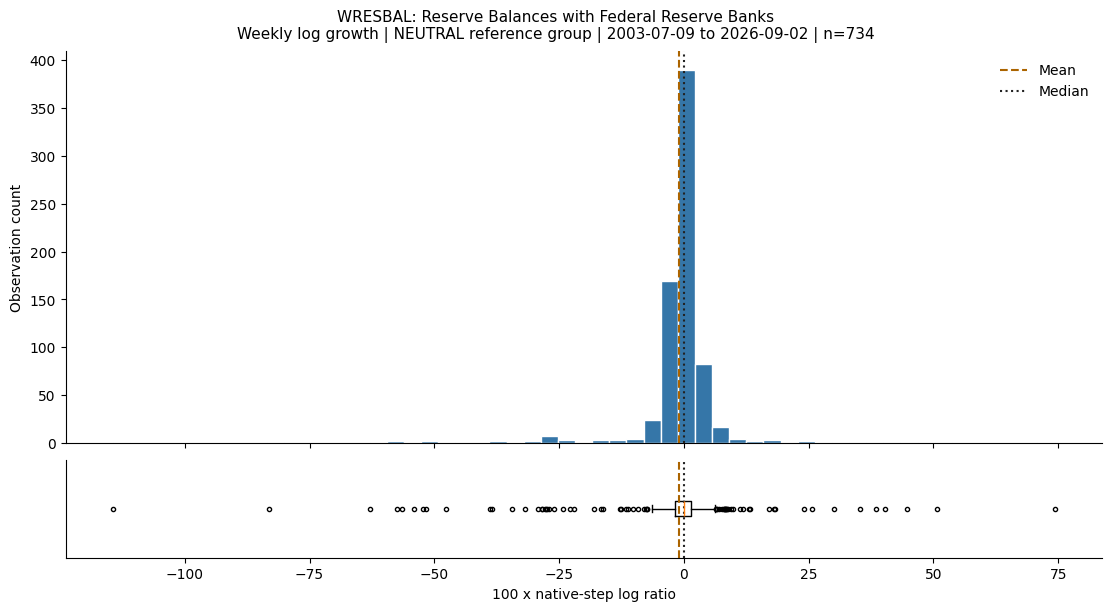

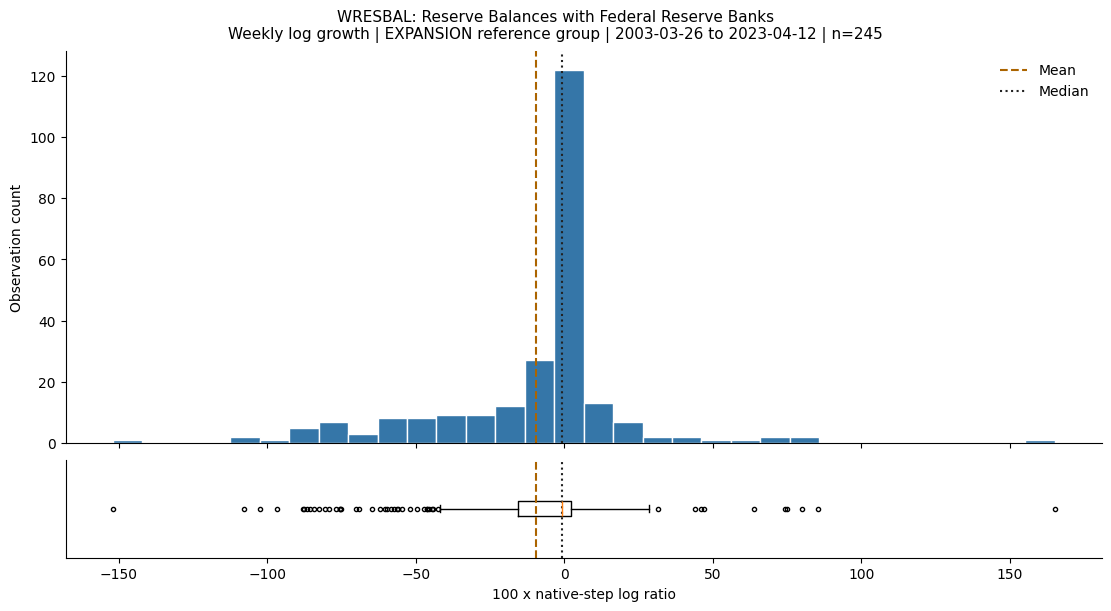

**Largest interpretation changes** (score differences, not evidence of better predictions):

date,delta,regime,global_z,global_robust_z,z_regime,robust_z_regime,robust_score_difference
2006-03-15,169.13,CONTRACTION,7.1743,52.668,5.0649,19.933,32.734
2007-08-15,153.15,CONTRACTION,6.4946,47.687,4.542,18.032,29.655
2008-09-17,165.07,EXPANSION,7.0015,51.401,5.2784,24.763,26.638
2006-03-08,-152.09,EXPANSION,-6.4893,-47.466,-4.3111,-22.633,24.833
2008-01-16,103.04,CONTRACTION,4.363,32.065,2.9019,12.069,19.996
2003-08-20,100.87,CONTRACTION,4.2707,31.389,2.8309,11.811,19.577
2007-08-22,-107.84,EXPANSION,-4.6068,-33.67,-2.973,-16.019,17.651
2005-01-19,88.936,CONTRACTION,3.7632,27.669,2.4404,10.392,17.278
2008-07-30,88.605,CONTRACTION,3.7491,27.566,2.4296,10.352,17.214
2005-02-09,-102.55,EXPANSION,-4.3818,-32.021,-2.8131,-15.229,16.792


date,delta,regime,global_z,global_robust_z,z_regime,robust_z_regime,percentile_regime
2026-09-09,3.2888,NEUTRAL,0.12005,0.9706,0.40561,1.3673,90.463


22.9% of available scores change by more than 1.0 score unit(s); minimum group n=245; instability screen=True. Conditioning makes context explicit, but it also changes the reference by construction. Next test window/threshold sensitivity and held-out calibration before preferring it to a global reference.

In [7]:
regime_experiment('WRESBAL')

## 6. TOTRESNS: structural-epoch experiments

Test two date partitions: before 2008-01-01 versus from 2008-01-01; and before 2008, 2008-2019, 2020 onward. These user-proposed boundaries are economic hypotheses, not estimated breaks or assumed monetary-system facts. Use both arithmetic and log changes (positive endpoints), preserving full history. Attribute a cross-boundary change to its ending-date epoch; it remains included and is shown below.

Report later-minus-earlier means/medians and later/earlier std and MAD ratios. Zero denominators yield undefined ratios. A scale ratio beyond 3 in either direction or center difference above one global standard deviation is an exploratory distribution-shift indicator, not a formal structural-break test. Serial dependence and unequal epoch lengths limit inference; no IID KS p-value is used. Conditioned scores use pre-latest references, and small groups remain unscored.

transform,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
level,811,659.52,"1,129.5",44.9,15,1.5449,0.89024,0,18,"4,193.2",18.51,19.7,34.95,44.9,912.7,"3,248","3,872.3"
arithmetic_delta,810,3.744,58.994,0.1,0.8,4.0425,62.328,0.048148,-325.1,854.2,-174.46,-56.12,-0.6,0.1,1.1,81.255,195.83
log_delta,810,0.62768,6.5804,0.47733,1.5318,9.7939,141.59,0.048148,-25.579,111.82,-8.5222,-4.9133,-1.1675,0.47733,1.8224,4.6264,12.92


partition,transform,epoch,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
epoch_two,log_delta,PRE_2008,587,0.14201,3.1002,0.47733,1.3159,1.3869,43.165,0.064736,-25.579,37.217,-6.343,-4.616,-1.0323,0.47733,1.5707,3.5951,5.5862
epoch_two,log_delta,POST_2008,222,1.9098,11.435,0.45186,2.3976,6.4888,52.469,0.0045045,-20.466,111.82,-10.401,-6.0788,-1.8595,0.45186,2.9261,10.624,59.312


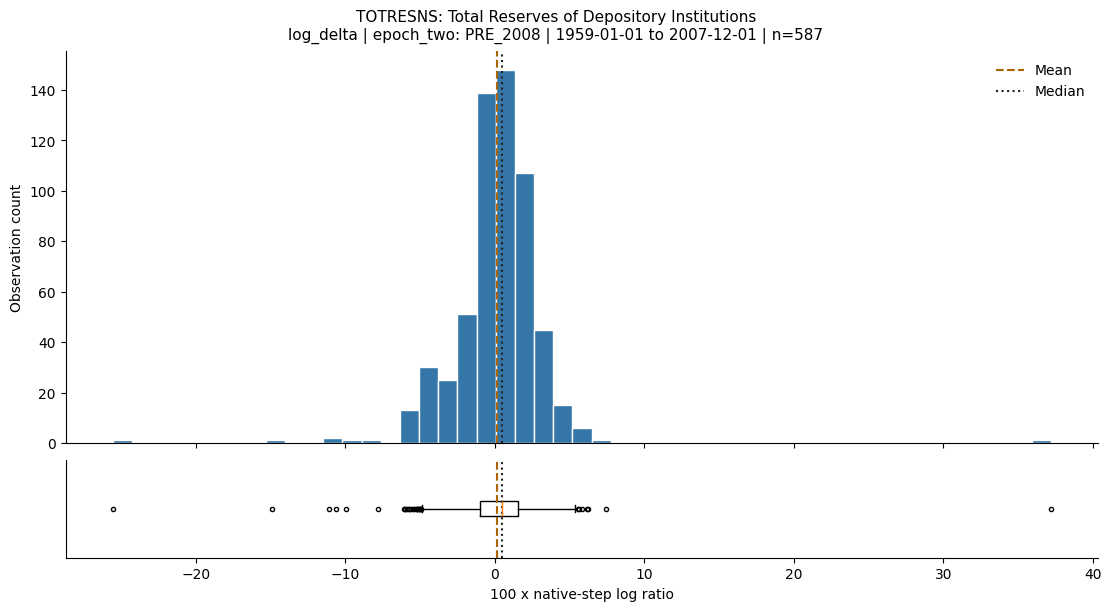

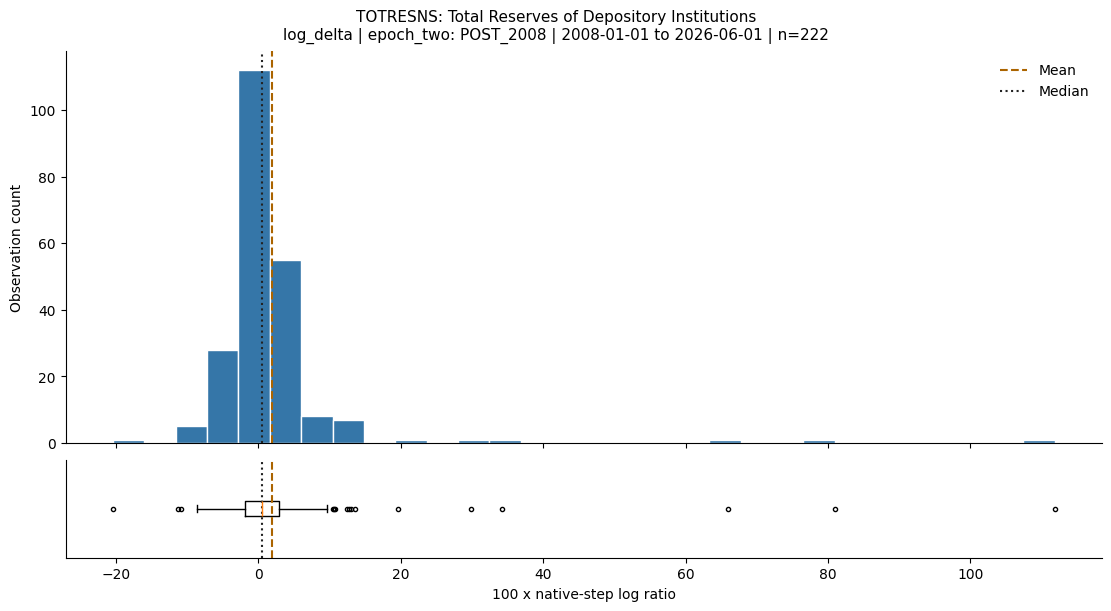

partition,transform,epoch,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
epoch_two,arithmetic_delta,PRE_2008,587,0.041908,1.446,0.1,0.5,1.3065,52.074,0.064736,-13,17.9,-3.198,-2.2,-0.4,0.1,0.6,1.6,2.5
epoch_two,arithmetic_delta,POST_2008,222,13.402,112.25,8.15,51.35,1.9011,14.857,0.0045045,-325.1,854.2,-289.48,-157.4,-41.15,8.15,61.525,170.94,356.08


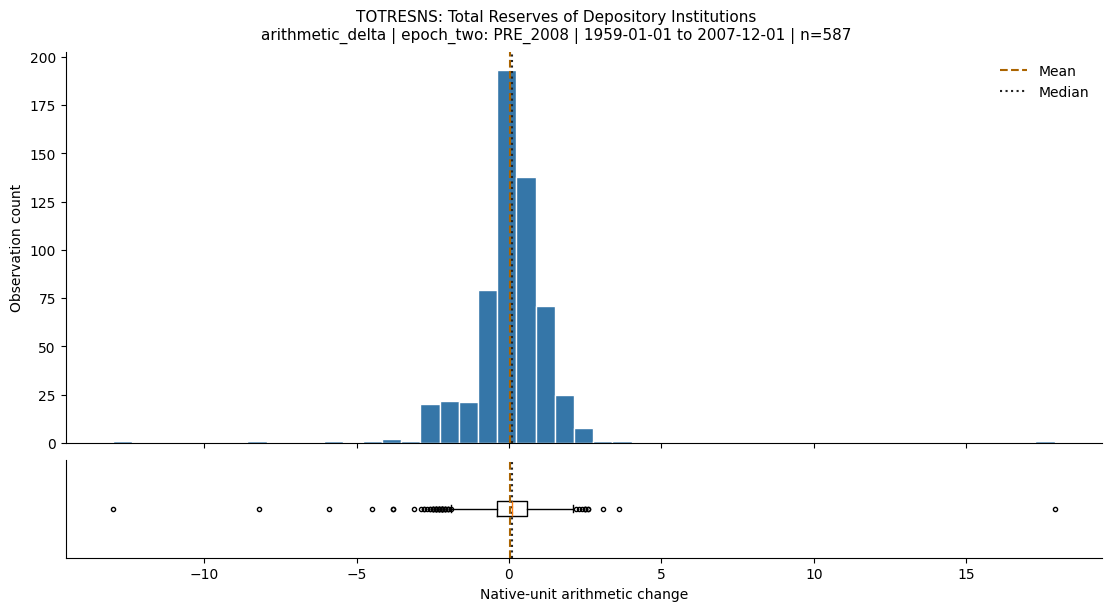

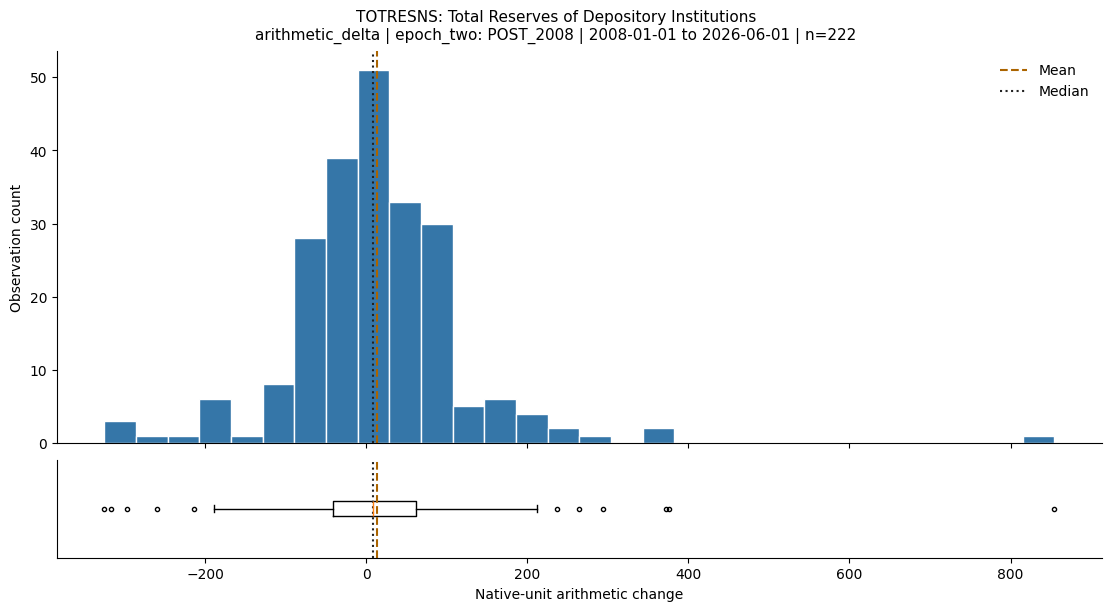

date,epoch_two,delta,global_z,z_conditioned,score_difference
2008-10-01,POST_2008,111.82,16.887,9.6119,7.2749
2001-09-01,PRE_2008,37.217,5.557,11.959,6.402
2008-09-01,POST_2008,80.947,12.198,6.9121,5.2862
2008-11-01,POST_2008,66.004,9.929,5.6053,4.3237
2001-10-01,PRE_2008,-25.579,-3.98,-8.2966,4.3166
1991-01-01,PRE_2008,-14.937,-2.3637,-4.8638,2.5001
2020-04-01,POST_2008,34.137,5.0893,2.8184,2.2708
2008-12-01,POST_2008,29.842,4.4369,2.4428,1.9941
1992-04-01,PRE_2008,-11.07,-1.7765,-3.6167,1.8402
2001-11-01,PRE_2008,-10.636,-1.7105,-3.4765,1.766


date,epoch_two,delta,global_z,z_conditioned,percentile_conditioned
2026-07-01,POST_2008,1.0774,0.068382,-0.072802,58.559


partition,transform,epoch,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
epoch_three,log_delta,PRE_2008,587,0.14201,3.1002,0.47733,1.3159,1.3869,43.165,0.064736,-25.579,37.217,-6.343,-4.616,-1.0323,0.47733,1.5707,3.5951,5.5862
epoch_three,log_delta,2008_TO_2019,144,2.5449,13.546,0.52523,2.5376,5.8267,39.729,0.0069444,-20.466,111.82,-9.4486,-5.7528,-1.9333,0.52523,3.4854,12.235,74.522
epoch_three,log_delta,2020_PLUS,78,0.73748,5.6859,0.39367,1.9228,2.9758,16.119,0,-11.296,34.137,-9.2101,-6.7649,-1.6956,0.39367,1.9631,7.6918,22.892


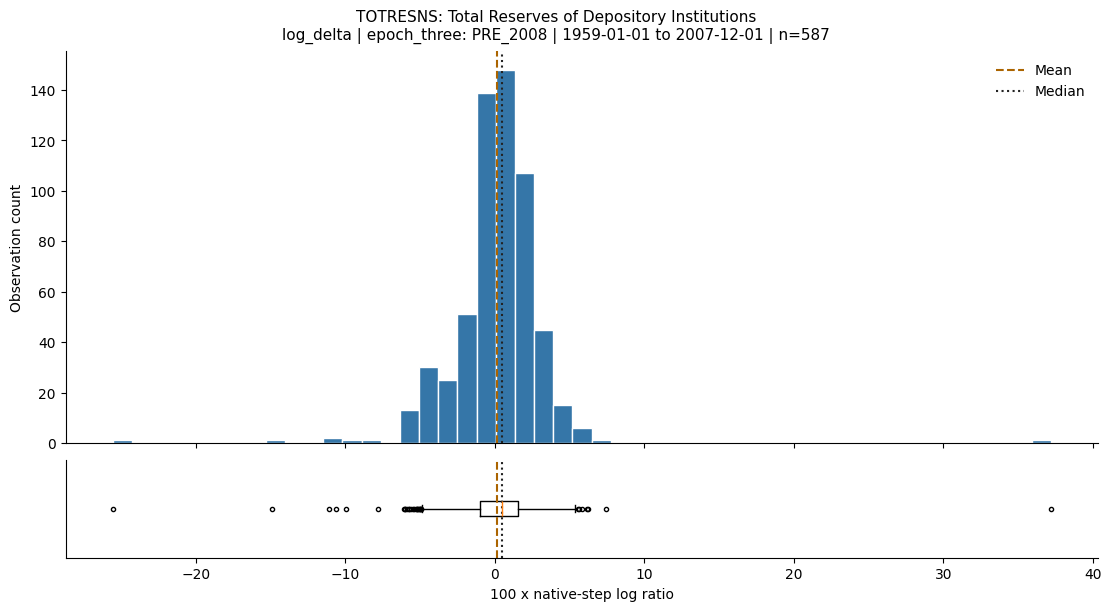

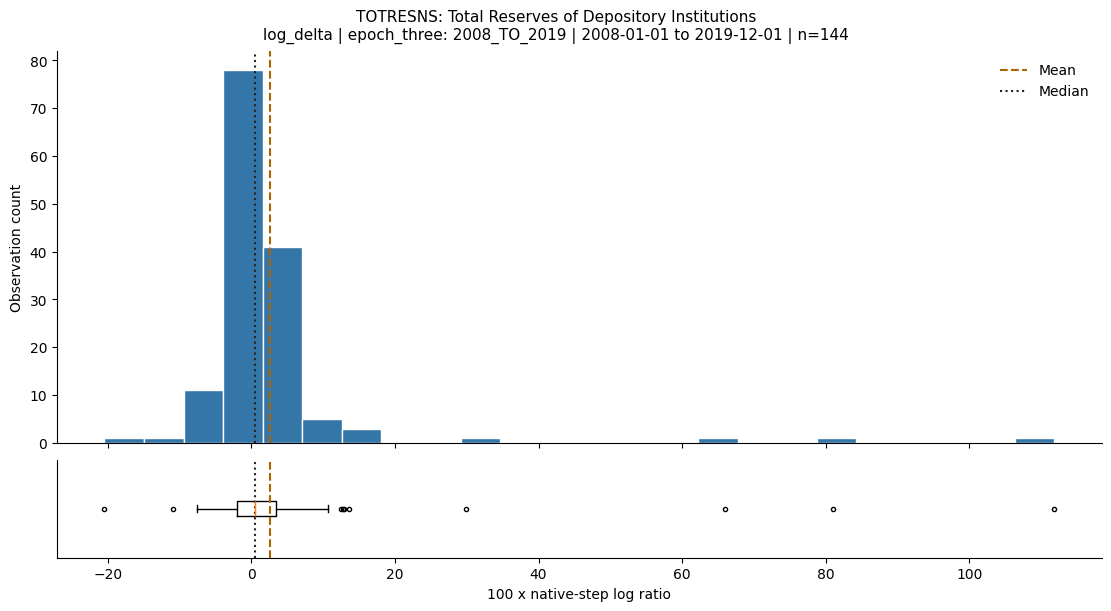

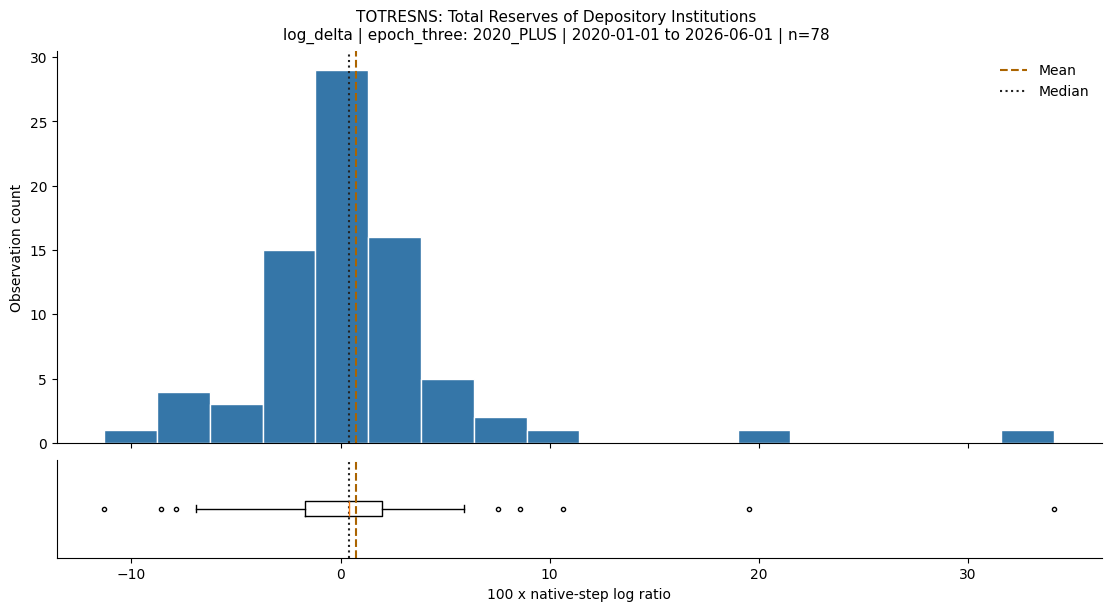

partition,transform,epoch,count,mean,std,median,MAD,skewness,kurtosis,zero_share,minimum,maximum,P1,P5,P25,P50,P75,P95,P99
epoch_three,arithmetic_delta,PRE_2008,587,0.041908,1.446,0.1,0.5,1.3065,52.074,0.064736,-13,17.9,-3.198,-2.2,-0.4,0.1,0.6,1.6,2.5
epoch_three,arithmetic_delta,2008_TO_2019,144,11.492,76.7,6.35,46.1,0.271,1.3541,0.0069444,-189.5,294.3,-182.58,-100.66,-38.1,6.35,62.15,130.95,211.86
epoch_three,arithmetic_delta,2020_PLUS,78,16.929,158.81,11.65,61.9,1.8501,9.7336,0,-325.1,854.2,-318.71,-220.63,-59.6,11.65,60.7,240.71,485.52


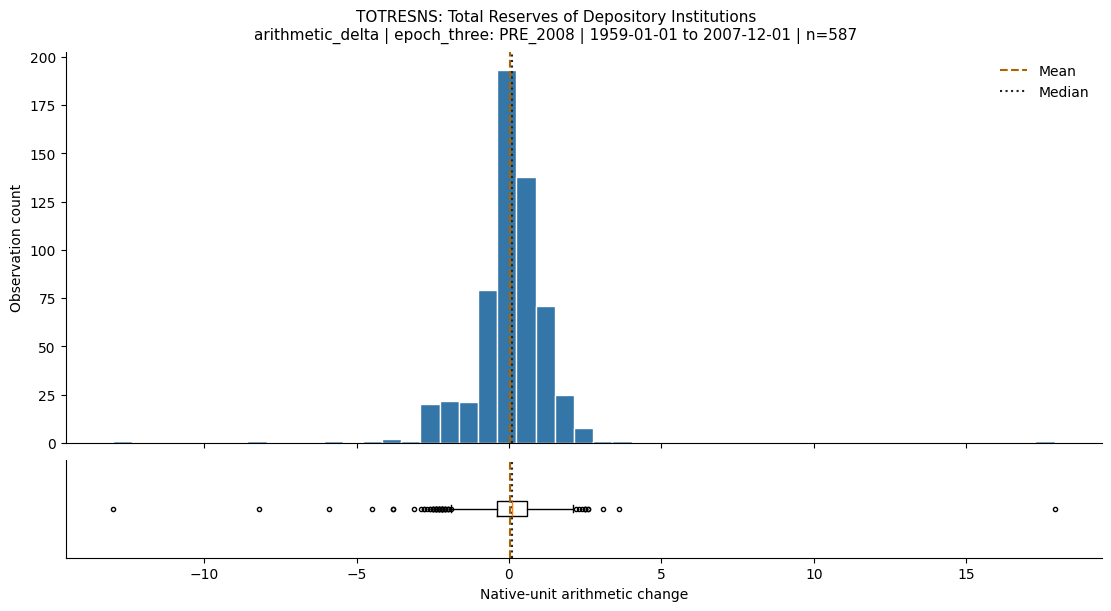

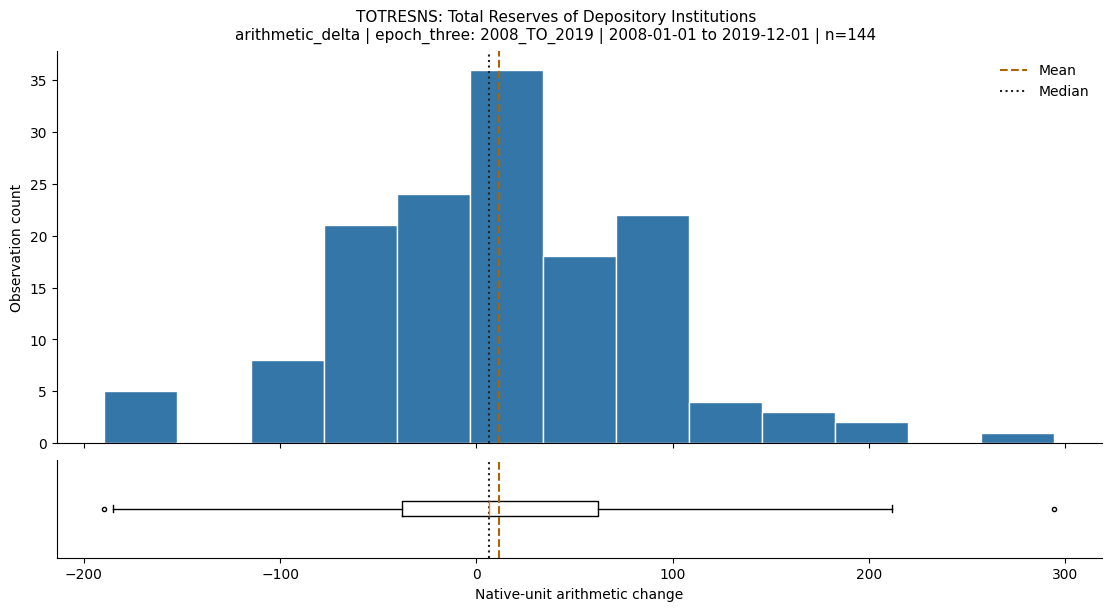

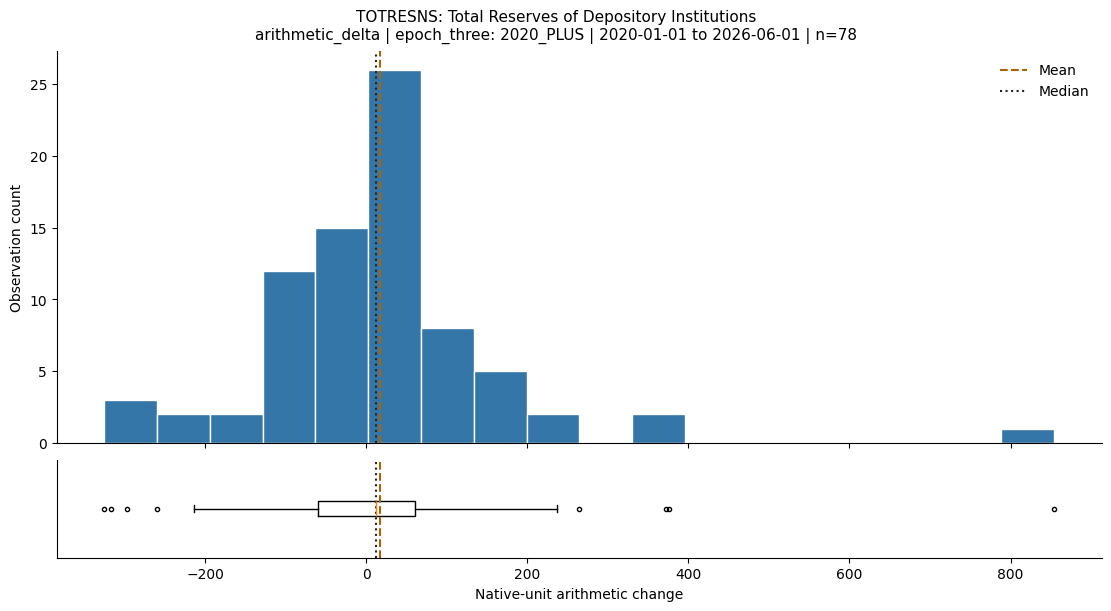

date,epoch_three,delta,global_z,z_conditioned,score_difference
2008-10-01,2008_TO_2019,111.82,16.887,8.0666,8.8202
2008-09-01,2008_TO_2019,80.947,12.198,5.7877,6.4107
2001-09-01,PRE_2008,37.217,5.557,11.959,6.402
2008-11-01,2008_TO_2019,66.004,9.929,4.6846,5.2444
2001-10-01,PRE_2008,-25.579,-3.98,-8.2966,4.3166
1991-01-01,PRE_2008,-14.937,-2.3637,-4.8638,2.5001
2008-12-01,2008_TO_2019,29.842,4.4369,2.0151,2.4218
1992-04-01,PRE_2008,-11.07,-1.7765,-3.6167,1.8402
2001-11-01,PRE_2008,-10.636,-1.7105,-3.4765,1.766
1984-02-01,PRE_2008,-9.9559,-1.6073,-3.2572,1.6499


date,epoch_three,delta,global_z,z_conditioned,percentile_conditioned
2026-07-01,2020_PLUS,1.0774,0.068382,0.059781,62.821


partition,transform,earlier,later,mean_difference,std_ratio,median_difference,MAD_ratio
epoch_two,log_delta,PRE_2008,POST_2008,1.7678,3.6884,-0.025472,1.822
epoch_two,arithmetic_delta,PRE_2008,POST_2008,13.36,77.627,8.05,102.7
epoch_three,log_delta,PRE_2008,2008_TO_2019,2.4029,4.3695,0.0479,1.9284
epoch_three,log_delta,PRE_2008,2020_PLUS,0.59547,1.8341,-0.083655,1.4612
epoch_three,log_delta,2008_TO_2019,2020_PLUS,-1.8074,0.41974,-0.13156,0.75774
epoch_three,arithmetic_delta,PRE_2008,2008_TO_2019,11.45,53.041,6.25,92.2
epoch_three,arithmetic_delta,PRE_2008,2020_PLUS,16.888,109.82,11.55,123.8
epoch_three,arithmetic_delta,2008_TO_2019,2020_PLUS,5.4378,2.0705,5.3,1.3427


**Changes assigned to a new epoch by ending date**

date,previous_level,level,delta,epoch_three
2008-01-01,43.5,44.9,3.1677,2008_TO_2019
2020-01-01,"1,698.3","1,715.2",0.99019,2020_PLUS


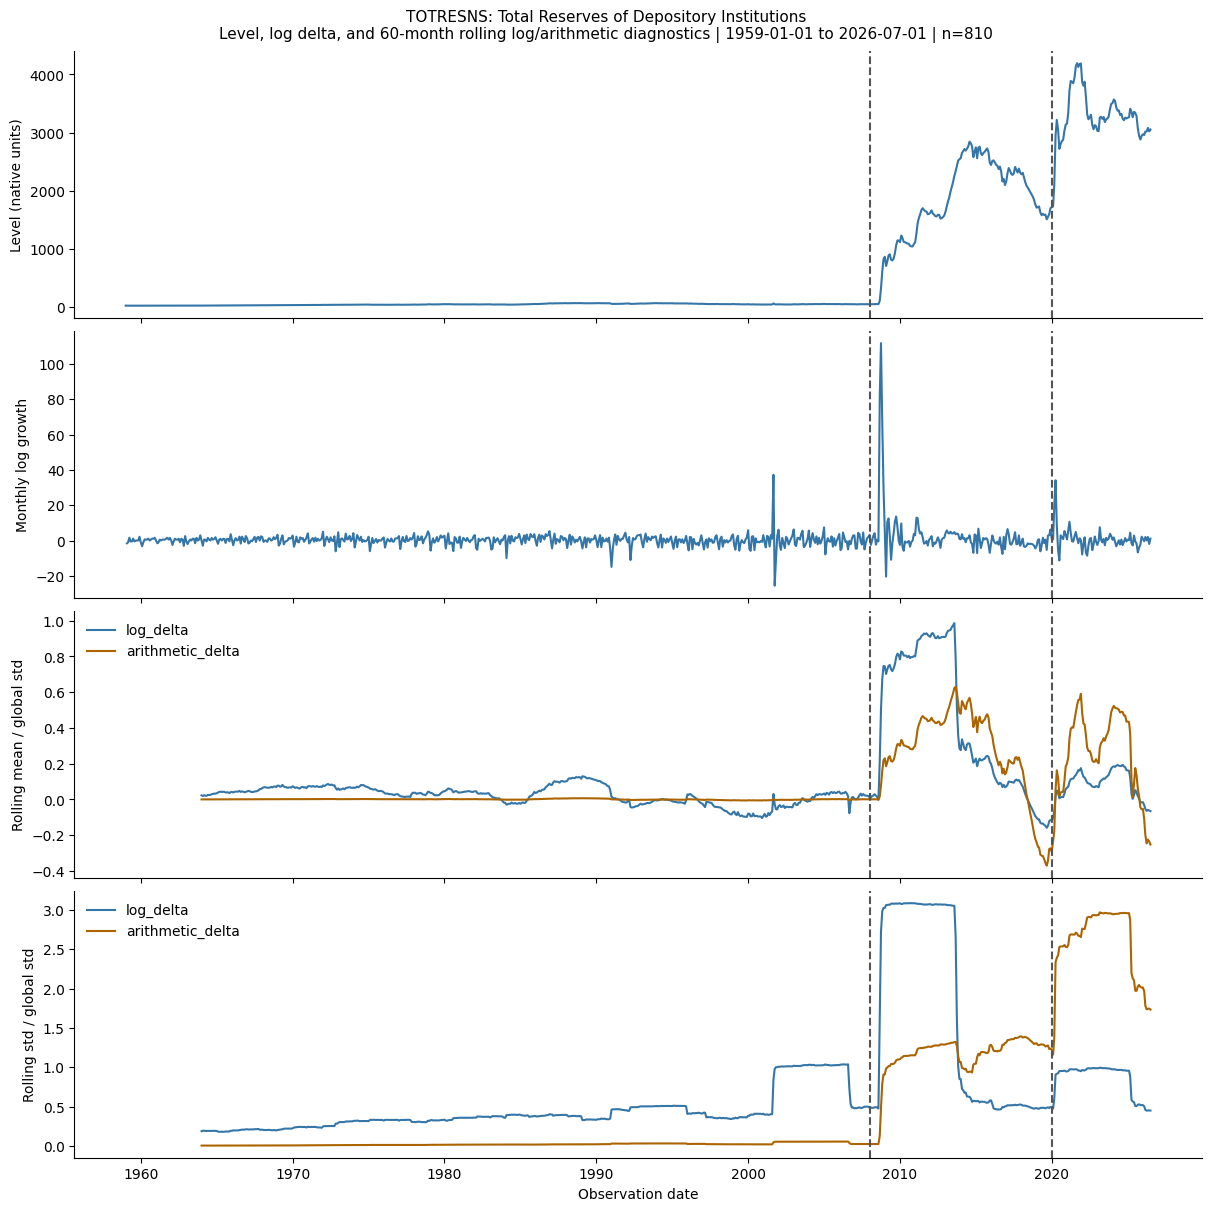

Epoch distribution-shift indicator=True; largest log std ratio 4.37; smallest 0.42. Differences support investigating segmentation, not treating these dates as validated breaks. Next vary boundaries and compare held-out calibration; inspect both arithmetic and log behavior and transitions at the boundaries.

In [8]:
tot=D['TOTRESNS'].copy()
tot['arithmetic_delta'],_=change(DATA['TOTRESNS'],'monthly','arithmetic')
tot['log_delta']=tot.delta
b2=pd.Timestamp(CONFIG['epochs_two'][0]);b31,b32=map(pd.Timestamp,CONFIG['epochs_three'])
tot['epoch_two']=np.where(tot.date<b2,'PRE_2008','POST_2008')
tot['epoch_three']=np.select([tot.date<b31,tot.date<b32],['PRE_2008','2008_TO_2019'],default='2020_PLUS')
EPOCH_TABLES=[];DISTANCES=[];EPOCH_SCORES={}
table(pd.DataFrame([{'transform':'level',**stats(tot.level)},{'transform':'arithmetic_delta',**stats(tot.arithmetic_delta)},{'transform':'log_delta',**stats(tot.log_delta)}]))
for partition in ['epoch_two','epoch_three']:
 for method in ['log_delta','arithmetic_delta']:
  epoch_rows=[]
  order=tot[partition].drop_duplicates().tolist()
  for epoch in order:
   part=tot.loc[tot.eligible&tot[partition].eq(epoch),method]
   epoch_rows.append({'partition':partition,'transform':method,'epoch':epoch,**stats(part)})
  report=pd.DataFrame(epoch_rows);EPOCH_TABLES.append(report);table(report)
  for earlier,later in itertools.combinations(order,2):
   a=report.set_index('epoch').loc[earlier];b=report.set_index('epoch').loc[later]
   DISTANCES.append({'partition':partition,'transform':method,'earlier':earlier,'later':later,
    'mean_difference':b['mean']-a['mean'],'std_ratio':b['std']/a['std'] if a['std']>0 else np.nan,
    'median_difference':b['median']-a['median'],'MAD_ratio':b.MAD/a.MAD if a.MAD>0 else np.nan})
  # Every distribution gets its own figure, retaining its complete tail range.
  for epoch in order:
   part=tot.loc[tot.eligible&tot[partition].eq(epoch)].copy();part['delta']=part[method]
   original_unit=UNITS.get('TOTRESNS')
   if method=='arithmetic_delta':UNITS['TOTRESNS']='Native-unit arithmetic change'
   hist('TOTRESNS',part,f'{method} | {partition}: {epoch}')
   if original_unit is None:UNITS.pop('TOTRESNS',None)
   else:UNITS['TOTRESNS']=original_unit
 scored,groups=group_scores(tot,partition);EPOCH_SCORES[partition]=scored
 scored['score_difference']=(scored.global_z-scored.z_conditioned).abs()
 table(scored.nlargest(10,'score_difference')[['date',partition,'delta','global_z','z_conditioned','score_difference']])
 table(scored.tail(1)[['date',partition,'delta','global_z','z_conditioned','percentile_conditioned']])
distance_table=pd.DataFrame(DISTANCES);table(distance_table)
boundary_mask=tot.epoch_three.ne(tot.epoch_three.shift())&tot.delta.notna()
display(Markdown('**Changes assigned to a new epoch by ending date**'));table(tot.loc[boundary_mask,['date','previous_level','level','delta','epoch_three']])
fig,axes=plt.subplots(4,1,figsize=(12,12),sharex=True,layout='constrained')
axes[0].plot(tot.date,tot.level,color='#3576A8');axes[0].set_ylabel('Level (native units)')
axes[1].plot(tot.date,tot.delta,color='#3576A8');axes[1].set_ylabel('Monthly log growth')
for method,color in [('log_delta','#3576A8'),('arithmetic_delta','#AB6400')]:
 # Standardize only for plotting comparable movement of rolling statistics; retain native summaries above.
 v=tot[method];scaled=v/v.loc[tot.eligible].std(ddof=1)
 axes[2].plot(tot.date,scaled.rolling(CONFIG['rolling_window_monthly']).mean(),color=color,label=method)
 axes[3].plot(tot.date,scaled.rolling(CONFIG['rolling_window_monthly']).std(),color=color,label=method)
axes[2].set_ylabel('Rolling mean / global std');axes[3].set(ylabel='Rolling std / global std',xlabel='Observation date')
for ax in axes:
 for boundary in [b31,b32]:ax.axvline(boundary,color='#555555',ls='--')
axes[2].legend(frameon=False);axes[3].legend(frameon=False)
fig.suptitle(caption('TOTRESNS',tot,'Level, log delta, and 60-month rolling log/arithmetic diagnostics'),fontsize=11)
plt.show();plt.close(fig)
log_dist=distance_table.loc[distance_table['transform'].eq('log_delta')]
scale_change=((log_dist.std_ratio>CONFIG['epoch_scale_ratio_threshold'])|(log_dist.std_ratio<1/CONFIG['epoch_scale_ratio_threshold'])).any()
center_change=log_dist.mean_difference.abs().max()/REF['TOTRESNS'].std()>CONFIG['epoch_center_shift_threshold']
structural_indicator=bool(scale_change or center_change)
DIAG['TOTRESNS']['structural_break_indicator']=structural_indicator
RESULTS['TOTRESNS']={'preliminary_fit':'PROMISING' if structural_indicator else 'MIXED',
 'main_normalization':'Epoch-conditioned log-delta z and ECDF','main_risk':'Assumed boundaries; regime mixtures can remain within epochs',
 'reason':f'Epoch distribution-shift indicator={structural_indicator}; largest log std ratio {log_dist.std_ratio.max():.2f}; smallest {log_dist.std_ratio.min():.2f}.'}
display(Markdown(RESULTS['TOTRESNS']['reason']+' Differences support investigating segmentation, not treating these dates as validated breaks. Next vary boundaries and compare held-out calibration; inspect both arithmetic and log behavior and transitions at the boundaries.'))


## Cross-series comparison and experimental router

Preliminary fits above are computed from displayed diagnostics: discrete models require substantial zero mass (UNRATE also requires observed shocks); ICSA requires standard/robust scale divergence; regime models require sufficient group size, measured instability and material score changes; epochs require measured cross-epoch differences. PROMISING means worth testing, not validated. Otherwise these experiments are MIXED.

Router inputs use pre-latest reference history. Tail ratio = std/(1.4826 MAD), using the documented IQR fallback if needed. Similar scales do not prove normality. A high ratio suggests the standard deviation is more influenced by tails. Rolling mean instability is the P90-P10 range of rolling means divided by robust scale; rolling std instability is P90/P10 of rolling std.

Decision order: zero share above threshold routes to DISCRETE_PLUS_SHOCK if tail ratio or excess kurtosis is high, otherwise DISCRETE_DELTA; high rolling instability or an epoch indicator routes to REGIME_ROBUST_DELTA if heavy-tailed, otherwise REGIME_DELTA; remaining heavy-tailed data routes to ROBUST_DELTA, else STANDARD_DELTA. The router does not infer economically meaningful epoch dates: TOTRESNS may still merit structural epochs even when routed to a generic regime family. A disagreement is a review item, not a failure to hide.

In [9]:
summary_rows=[];router_rows=[]
for sid in IDS:
 ref=REF[sid];st=stats(ref);diag=DIAG[sid];heavy=diag['tail_ratio']>CONFIG['tail_ratio_threshold']
 strong=heavy or st['kurtosis']>CONFIG['strong_excess_kurtosis']
 structural=diag['structural_instability_high'] or diag.get('structural_break_indicator',False)
 if st['zero_share']>CONFIG['zero_share_threshold']:route='DISCRETE_PLUS_SHOCK' if strong else 'DISCRETE_DELTA'
 elif structural:route='REGIME_ROBUST_DELTA' if heavy else 'REGIME_DELTA'
 elif heavy:route='ROBUST_DELTA'
 else:route='STANDARD_DELTA'
 router_rows.append({'series':sid,'zero_change_share':st['zero_share'],**diag,'heavy_tail':heavy,'router_candidate':route,'tested_candidate':MODELS[sid]})
 result=RESULTS[sid]
 summary_rows.append({'series':sid,'candidate_model':MODELS[sid],'primary_transform':METHODS[sid],
 'zero_share':st['zero_share'],'skewness':st['skewness'],'kurtosis':st['kurtosis'],
 'structural_instability':structural,'regime_sensitivity':REGIME_EFFECT.get(sid,'Epoch comparisons' if sid=='TOTRESNS' else 'Not tested'),
 'tail_problem':strong,'main_normalization':result['main_normalization'],'main_risk':result['main_risk'],'preliminary_fit':result['preliminary_fit']})
comparison=pd.DataFrame(summary_rows);router=pd.DataFrame(router_rows)
table(comparison);table(router)


series,candidate_model,primary_transform,zero_share,skewness,kurtosis,structural_instability,regime_sensitivity,tail_problem,main_normalization,main_risk,preliminary_fit
AWHAETP,DISCRETE_DELTA,arithmetic,0.47951,-0.0082475,3.7582,False,Not tested,False,PMF / ECDF / exact-value rarity,Sparse transitions and precision-dependent point probabilities,PROMISING
ICSA,ROBUST_DELTA,log,0.031481,14.557,497.88,False,Not tested,True,Median/MAD robust z + ECDF,Crisis clustering; no proof of temporal stability,PROMISING
UNRATE,DISCRETE_PLUS_SHOCK,arithmetic,0.24468,16.713,428.68,False,Not tested,True,Discrete PMF + modified-z shock detector,Shock thresholds and zero-scale fallback need review,PROMISING
WALCL,REGIME_DELTA,log,0,6.1395,74.886,True,0.067755,True,Within-regime standard and robust z + ECDF,Retrospective thresholds; speed buckets are not identified policy regimes,PROMISING
WRESBAL,REGIME_ROBUST_DELTA,log,0,0.45738,11.467,True,0.22857,True,Within-regime median/MAD + ECDF,Retrospective thresholds; speed buckets are not identified policy regimes,PROMISING
TOTRESNS,STRUCTURAL_EPOCH_DELTA,log,0.048208,9.7882,141.41,True,Epoch comparisons,True,Epoch-conditioned log-delta z and ECDF,Assumed boundaries; regime mixtures can remain within epochs,PROMISING


series,zero_change_share,tail_ratio,rolling_mean_instability,rolling_std_instability,lag1_autocorrelation,structural_instability_high,heavy_tail,router_candidate,tested_candidate,structural_break_indicator
AWHAETP,0.47951,0.67449,0.085435,1.8198,-0.40413,False,False,DISCRETE_DELTA,DISCRETE_DELTA,NaN
ICSA,0.031481,1.762,0.46789,2.8641,0.043907,False,True,ROBUST_DELTA,ROBUST_DELTA,NaN
UNRATE,0.24468,2.7877,0.66325,2.333,0.035681,False,True,DISCRETE_PLUS_SHOCK,DISCRETE_PLUS_SHOCK,NaN
WALCL,0,3.1881,1.6492,8.5781,0.37154,True,True,REGIME_ROBUST_DELTA,REGIME_DELTA,NaN
WRESBAL,0,7.3285,0.93306,31.269,-0.71779,True,True,REGIME_ROBUST_DELTA,REGIME_ROBUST_DELTA,NaN
TOTRESNS,0.048208,2.8923,0.81208,4.4087,0.55641,True,True,REGIME_ROBUST_DELTA,STRUCTURAL_EPOCH_DELTA,True


# Experimental Findings

The following findings and verdicts are generated from this run. PROMISING WITH CAUTION denotes a promising descriptive fit that still needs temporal validation or more defensible group definitions. None of the experiments establishes predictive superiority.

In [10]:
final_rows=[]
for sid in IDS:
 result=RESULTS[sid];fit=result['preliminary_fit']
 verdict='PROMISING WITH CAUTION' if fit=='PROMISING' else 'NEEDS MORE TESTING' if fit=='MIXED' else 'POOR FIT'
 display(Markdown(f"### {sid} - {NAMES[sid]}\n\n**Tested:** {MODELS[sid]}. **Result:** {verdict}.\n\n"
  f"**Observed behavior / potential improvement:** {result['reason']}\n\n"
  f"**Remaining problem:** {result['main_risk']}.\n\n"
  '**Next manual audit:** vary thresholds, examine sparse groups and historical subperiods, and evaluate expanding-window or held-out reference estimates. '
  'Conditioned or robust scores are descriptive alternatives; smaller in-group dispersion is not by itself a performance gain.'))
 final_rows.append({'Series':sid,'Candidate model':MODELS[sid],'Current verdict':verdict,'Main reason':result['reason']})
table(pd.DataFrame(final_rows))
assert len(comparison)==6 and set(comparison.series)==set(IDS)
assert all(digest(ROOT/path)==h for path,h in hashes.items())
assert all(len(D[s])==len(DATA[s]) for s in IDS)
print('Source CSVs and all pre-existing notebooks unchanged; all historical rows retained.')
print('Python',platform.python_version(),'pandas',pd.__version__,'NumPy',np.__version__,'SciPy',scipy.__version__,'matplotlib',matplotlib.__version__)
table(pd.DataFrame([{'source':path,'sha256':h} for path,h in hashes.items() if any(path.endswith('/'+sid+'.csv') or path.endswith('\\'+sid+'.csv') for sid in IDS)]))
display(Markdown('This notebook does not finalize CHronoZ benchmark methodology. It is an experimental model-selection audit intended for manual review.'))


### AWHAETP - Average Weekly Hours: Total Private

**Tested:** DISCRETE_DELTA. **Result:** PROMISING WITH CAUTION.

**Observed behavior / potential improvement:** Zero share 48.0%; 8 distinct recorded steps support a discrete representation.

**Remaining problem:** Sparse transitions and precision-dependent point probabilities.

**Next manual audit:** vary thresholds, examine sparse groups and historical subperiods, and evaluate expanding-window or held-out reference estimates. Conditioned or robust scores are descriptive alternatives; smaller in-group dispersion is not by itself a performance gain.

### ICSA - Initial Claims

**Tested:** ROBUST_DELTA. **Result:** PROMISING WITH CAUTION.

**Observed behavior / potential improvement:** Standard/robust scale ratio 1.76; 84 observations flagged but retained.

**Remaining problem:** Crisis clustering; no proof of temporal stability.

**Next manual audit:** vary thresholds, examine sparse groups and historical subperiods, and evaluate expanding-window or held-out reference estimates. Conditioned or robust scores are descriptive alternatives; smaller in-group dispersion is not by itself a performance gain.

### UNRATE - Unemployment Rate

**Tested:** DISCRETE_PLUS_SHOCK. **Result:** PROMISING WITH CAUTION.

**Observed behavior / potential improvement:** Zero share 24.5%; 25 shocks; native precision 1 decimal place(s).

**Remaining problem:** Shock thresholds and zero-scale fallback need review.

**Next manual audit:** vary thresholds, examine sparse groups and historical subperiods, and evaluate expanding-window or held-out reference estimates. Conditioned or robust scores are descriptive alternatives; smaller in-group dispersion is not by itself a performance gain.

### WALCL - Federal Reserve Total Assets

**Tested:** REGIME_DELTA. **Result:** PROMISING WITH CAUTION.

**Observed behavior / potential improvement:** 6.8% of available scores change by more than 1.0 score unit(s); minimum group n=245; instability screen=True.

**Remaining problem:** Retrospective thresholds; speed buckets are not identified policy regimes.

**Next manual audit:** vary thresholds, examine sparse groups and historical subperiods, and evaluate expanding-window or held-out reference estimates. Conditioned or robust scores are descriptive alternatives; smaller in-group dispersion is not by itself a performance gain.

### WRESBAL - Reserve Balances with Federal Reserve Banks

**Tested:** REGIME_ROBUST_DELTA. **Result:** PROMISING WITH CAUTION.

**Observed behavior / potential improvement:** 22.9% of available scores change by more than 1.0 score unit(s); minimum group n=245; instability screen=True.

**Remaining problem:** Retrospective thresholds; speed buckets are not identified policy regimes.

**Next manual audit:** vary thresholds, examine sparse groups and historical subperiods, and evaluate expanding-window or held-out reference estimates. Conditioned or robust scores are descriptive alternatives; smaller in-group dispersion is not by itself a performance gain.

### TOTRESNS - Total Reserves of Depository Institutions

**Tested:** STRUCTURAL_EPOCH_DELTA. **Result:** PROMISING WITH CAUTION.

**Observed behavior / potential improvement:** Epoch distribution-shift indicator=True; largest log std ratio 4.37; smallest 0.42.

**Remaining problem:** Assumed boundaries; regime mixtures can remain within epochs.

**Next manual audit:** vary thresholds, examine sparse groups and historical subperiods, and evaluate expanding-window or held-out reference estimates. Conditioned or robust scores are descriptive alternatives; smaller in-group dispersion is not by itself a performance gain.

Series,Candidate model,Current verdict,Main reason
AWHAETP,DISCRETE_DELTA,PROMISING WITH CAUTION,Zero share 48.0%; 8 distinct recorded steps support a discrete representation.
ICSA,ROBUST_DELTA,PROMISING WITH CAUTION,Standard/robust scale ratio 1.76; 84 observations flagged but retained.
UNRATE,DISCRETE_PLUS_SHOCK,PROMISING WITH CAUTION,Zero share 24.5%; 25 shocks; native precision 1 decimal place(s).
WALCL,REGIME_DELTA,PROMISING WITH CAUTION,6.8% of available scores change by more than 1.0 score unit(s); minimum group n=245; instability screen=True.
WRESBAL,REGIME_ROBUST_DELTA,PROMISING WITH CAUTION,22.9% of available scores change by more than 1.0 score unit(s); minimum group n=245; instability screen=True.
TOTRESNS,STRUCTURAL_EPOCH_DELTA,PROMISING WITH CAUTION,Epoch distribution-shift indicator=True; largest log std ratio 4.37; smallest 0.42.


Source CSVs and all pre-existing notebooks unchanged; all historical rows retained.
Python 3.14.2 pandas 3.0.2 NumPy 2.4.4 SciPy 1.17.1 matplotlib 3.10.8


source,sha256
data\cleaned\AWHAETP.csv,5e13c1384dcc2272a903fd01464b109170018146f7afe13ea93198b611b19db6
data\cleaned\ICSA.csv,2d6b08b63c26ce5515751409912aa6cd951df9120d7e5a24c2121ce1bdcc20a6
data\cleaned\TOTRESNS.csv,1c667469b0261afb2594a14d3eeaaad7842f918c6929daa0df4756e194415ca5
data\cleaned\UNRATE.csv,b131bd5595fc5984bf2ff453aad399616573fe586c9acac57aeb95a93ea4ab44
data\cleaned\WALCL.csv,2ce364aa1b0394d3caa99290902c7fd0a4319c794e543f791b33850287092513
data\cleaned\WRESBAL.csv,6ce438e5c203ff5b84a02b359195178b462909813aa4993b672641e30f7696ed


This notebook does not finalize CHronoZ benchmark methodology. It is an experimental model-selection audit intended for manual review.